# Run Simulation

In [1]:
# import logging
# logging.basicConfig(level=logging.DEBUG)
# import sys
# sys.path.insert(0, "/Users/ddw/Desktop/Rescheduling")
# from run_simulation import run_simulation
# from utils.metrics import compute_metrics

# state, df, meta, _ = run_simulation(
#     n_freight            = 182,
#     trigger_strategy     = "periodic",
#     event_driven_freq    = 900,
#     mc_delay_per_train   = 40,
#     controller_freq      = 450,
#     periodic_freq        = 900,
#     threshold_confidence = 0.4,
#     objective_strategy   = "static",
#     upgrade_weight = 0,
#     weight_passenger     = 1,
#     weight_freight       = 1,
#     dynamic_threshold    = 180,
#     seed                 = 2,
#     save                 = False,
# )

# if meta["deadlock_detected"]:
#     print("DEADLOCK gedetecteerd — run incomplete, metrics niet beschikbaar.")
# else:
#     metrics = compute_metrics(df)
#     print(f"TED_passenger : {metrics['TED_passenger']:,.0f}s")
#     print(f"TED_freight   : {metrics['TED_freight']:,.0f}s")
#     print(f"TED_combined  : {metrics['TED_combined']:,.0f}s")
#     print(f"delay_ratio   : {metrics['delay_ratio']:.3f}" if metrics['delay_ratio'] else "delay_ratio   : N/A")
#     print(f"n_rescheduled : {meta['controller_summary']['n_rescheduled']}")

In [7]:
import logging
logging.basicConfig(level=logging.DEBUG)

import sys
sys.path.insert(0, "/Users/ddw/Desktop/Rescheduling")

from run_simulation import run_simulation
from utils.metrics import compute_metrics
from data.loader import load_all


# ------------------------------------------------------------
# LOAD DOMAIN OBJECTS
# ------------------------------------------------------------

trains, segments, timetable = load_all(n_freight=182)


# ------------------------------------------------------------
# RUN SIMULATION
# ------------------------------------------------------------

state, df, meta, _ , simulator= run_simulation(
        n_freight            = 182,
        trigger_strategy     = "periodic",
        event_driven_freq    = 900,
        mc_delay_per_train   = 120,
        controller_freq      = 450,
        periodic_freq        = 900,
        threshold_confidence = 0.6,
        objective_strategy   = "static",
        upgrade_weight       = 0,
        weight_passenger     = 1,
        weight_freight       = 1,
        dynamic_threshold    = 300,
        duration_statistic   = "scheduled",
        queue_mode           = "fsfs",
        min_objective_improvement=-1000.0,

        seed                 = 0,
        save                 = False,
        
    )


# ------------------------------------------------------------
# METRICS
# ------------------------------------------------------------

if meta["deadlock_detected"]:
    print("DEADLOCK gedetecteerd — run incomplete, metrics niet beschikbaar.")
else:
    metrics = compute_metrics(df, trains)

    print(f"TED_passenger : {metrics['TED_passenger']:,.0f}s")
    print(f"TED_freight   : {metrics['TED_freight']:,.0f}s")
    print(f"TED_combined  : {metrics['TED_combined']:,.0f}s")
    print(
        f"delay_ratio   : {metrics['delay_ratio']:.3f}"
        if metrics['delay_ratio']
        else "delay_ratio   : N/A"
    )
    print(f"n_rescheduled : {meta['controller_summary']['n_rescheduled']}")


# ------------------------------------------------------------
# DEBUG FUNCTION
# ------------------------------------------------------------

import pandas as pd


def compare_train(train_id, state, timetable, trains):

    rows = []

    train = trains[train_id]

    for seg in train.path:

        sched_entry = timetable.scheduled_entry(train_id, seg)
        sched_exit  = timetable.scheduled_exit(train_id, seg)

        try:
            actual_entry = state.actual_entry(train_id, seg)
        except KeyError:
            actual_entry = None

        try:
            actual_exit = state.actual_exit(train_id, seg)
        except KeyError:
            actual_exit = None

        entry_delay = (
            actual_entry - sched_entry
            if actual_entry is not None else None
        )

        exit_delay = (
            actual_exit - sched_exit
            if actual_exit is not None else None
        )

        rows.append({
            "segment": seg,
            "scheduled_entry": sched_entry,
            "actual_entry": actual_entry,
            "entry_delay": entry_delay,
            "scheduled_exit": sched_exit,
            "actual_exit": actual_exit,
            "exit_delay": exit_delay,
        })

    df_debug = pd.DataFrame(rows)

    numeric_cols = [
        "scheduled_entry",
        "actual_entry",
        "entry_delay",
        "scheduled_exit",
        "actual_exit",
        "exit_delay",
    ]

    df_debug[numeric_cols] = df_debug[numeric_cols].round(1)

    return df_debug

# print(f"{stat}: mean_delay={df['entry_delay'].mean():.0f}s")
# ------------------------------------------------------------
# EXAMPLE
# ------------------------------------------------------------

display(compare_train(900002, state, timetable, trains))

INFO:data.timetable:Gold geladen (passenger): 1028 treinen, 10072 segmenten
INFO:data.timetable:Gold geladen (freight): 182 treinen, 654 segmenten
INFO:data.timetable:Track assignment diagnostics:
  BRUSSEL-CENTRAAL (alle): 965 toewijzingen, 0 capaciteitsconflicten, 0 ongeldige intervallen
  BRUSSEL-CONGRES (alle): 965 toewijzingen, 0 capaciteitsconflicten, 0 ongeldige intervallen
  BRUSSEL-KAPELLEKERK (alle): 965 toewijzingen, 0 capaciteitsconflicten, 0 ongeldige intervallen
INFO:data.combine_timetable:Track assignment diagnostics:
  BRUSSEL-CENTRAAL (alle): 965 toewijzingen, 0 capaciteitsconflicten, 0 ongeldige intervallen
  BRUSSEL-CONGRES (alle): 965 toewijzingen, 0 capaciteitsconflicten, 0 ongeldige intervallen
  BRUSSEL-KAPELLEKERK (alle): 965 toewijzingen, 0 capaciteitsconflicten, 0 ongeldige intervallen
INFO:data.combine_timetable:Gecombineerd: 1210 treinen (1028 passenger, 182 freight), 10726 segmenten
INFO:data.loader:Treinen geladen: 1210
INFO:data.loader:Segmenten geladen: 

Loading data...


INFO:data.timetable:Track assignment diagnostics:
  BRUSSEL-CENTRAAL (alle): 965 toewijzingen, 0 capaciteitsconflicten, 0 ongeldige intervallen
  BRUSSEL-CONGRES (alle): 965 toewijzingen, 0 capaciteitsconflicten, 0 ongeldige intervallen
  BRUSSEL-KAPELLEKERK (alle): 965 toewijzingen, 0 capaciteitsconflicten, 0 ongeldige intervallen
INFO:data.combine_timetable:Track assignment diagnostics:
  BRUSSEL-CENTRAAL (alle): 965 toewijzingen, 0 capaciteitsconflicten, 0 ongeldige intervallen
  BRUSSEL-CONGRES (alle): 965 toewijzingen, 0 capaciteitsconflicten, 0 ongeldige intervallen
  BRUSSEL-KAPELLEKERK (alle): 965 toewijzingen, 0 capaciteitsconflicten, 0 ongeldige intervallen
INFO:data.combine_timetable:Gecombineerd: 1210 treinen (1028 passenger, 182 freight), 10726 segmenten
INFO:data.loader:Treinen geladen: 1210
INFO:data.loader:Segmenten geladen: 192
INFO:data.loader:Timetable geladen: 10726 (train_no, segment_id) combinaties
DEBUG:simulation.dispatcher:priority_winner: MIP-prioriteit veroud

Building controller (trigger=periodic, objective=static)...
Running simulation...
[t=906] T=23 S=44 conf=134 vars=443 constr=579 bin=134
[t=906s] SKIPPED_NO_IMPROVEMENT — MIP=388s, FCFS=388s, improvement=0s < threshold=60s
[t=1835] T=23 S=22 conf=142 vars=382 constr=521 bin=142
[t=1835s] SKIPPED_NO_IMPROVEMENT — MIP=458s, FCFS=459s, improvement=1s < threshold=60s
[t=2772] T=22 S=20 conf=136 vars=349 constr=483 bin=136
[t=2772s] SKIPPED_NO_IMPROVEMENT — MIP=762s, FCFS=762s, improvement=-0s < threshold=60s
[t=3830] T=24 S=20 conf=130 vars=367 constr=491 bin=130
[t=3830s] SKIPPED_NO_IMPROVEMENT — MIP=441s, FCFS=441s, improvement=-0s < threshold=60s
[t=4742] T=22 S=19 conf=103 vars=310 constr=409 bin=103
[t=4742s] SKIPPED_NO_IMPROVEMENT — MIP=560s, FCFS=560s, improvement=-0s < threshold=60s
[t=5771] T=19 S=18 conf=115 vars=322 constr=436 bin=115
[t=5771s] SKIPPED_NO_IMPROVEMENT — MIP=1148s, FCFS=1148s, improvement=-0s < threshold=60s
[t=6676] T=19 S=18 conf=115 vars=316 constr=430 bin=115


DEBUG:simulation.dispatcher:priority_winner: MIP-prioriteit verouderd (1331s geleden, TTL=1200s) voor seg=0-2:BRUSSEL-KAPELLEKERK-BRUSSEL-ZUID — gebruik scheduled_entry
DEBUG:simulation.dispatcher:priority_winner: MIP-prioriteit verouderd (1331s geleden, TTL=1200s) voor seg=0-2:BRUSSEL-KAPELLEKERK-BRUSSEL-ZUID — gebruik scheduled_entry
DEBUG:simulation.dispatcher:priority_winner: MIP-prioriteit verouderd (1635s geleden, TTL=1200s) voor seg=25:BRUSSEL-NOORD-SCHAARBEEK — gebruik scheduled_entry
DEBUG:simulation.dispatcher:priority_winner: MIP-prioriteit verouderd (1635s geleden, TTL=1200s) voor seg=25:BRUSSEL-NOORD-SCHAARBEEK — gebruik scheduled_entry


...

DEBUG:simulation.dispatcher:priority_winner: MIP-prioriteit verouderd (2286s geleden, TTL=1200s) voor seg=36N:SCHAARBEEK-BRUSSEL-NOORD — gebruik scheduled_entry
DEBUG:simulation.dispatcher:priority_winner: MIP-prioriteit verouderd (2286s geleden, TTL=1200s) voor seg=36N:SCHAARBEEK-BRUSSEL-NOORD — gebruik scheduled_entry
DEBUG:simulation.dispatcher:priority_winner: MIP-prioriteit verouderd (3146s geleden, TTL=1200s) voor seg=36N:SCHAARBEEK-BRUSSEL-NOORD — gebruik scheduled_entry
DEBUG:simulation.dispatcher:priority_winner: MIP-prioriteit verouderd (3146s geleden, TTL=1200s) voor seg=36N:SCHAARBEEK-BRUSSEL-NOORD — gebruik scheduled_entry


[t=76560s] SKIPPED_NO_IMPROVEMENT — MIP=1989s, FCFS=1989s, improvement=0s < threshold=60s
[t=77460] T=69 S=109 conf=1615 vars=3346 constr=5078 bin=1615
[t=77460s] SKIPPED_NO_IMPROVEMENT — MIP=227s, FCFS=284s, improvement=57s < threshold=60s
[t=78360] T=67 S=107 conf=1504 vars=3196 constr=4816 bin=1504
[t=78360s] SKIPPED_NO_IMPROVEMENT — MIP=253s, FCFS=253s, improvement=0s < threshold=60s
[t=79260] T=63 S=110 conf=1311 vars=2877 constr=4289 bin=1311
[t=79260s] SKIPPED_NO_IMPROVEMENT — MIP=181s, FCFS=181s, improvement=0s < threshold=60s
[t=80160] T=61 S=103 conf=1175 vars=2621 constr=3891 bin=1175
[t=80160s] RESCHEDULED — status=optimal, objective=343.70, solver_runtime=0.04s


DEBUG:simulation.dispatcher:priority_winner: MIP-prioriteit verouderd (1470s geleden, TTL=1200s) voor seg=0-3:BRUSSEL-CONGRES-BRUSSEL-NOORD — gebruik scheduled_entry
DEBUG:simulation.dispatcher:priority_winner: MIP-prioriteit verouderd (1470s geleden, TTL=1200s) voor seg=0-3:BRUSSEL-CONGRES-BRUSSEL-NOORD — gebruik scheduled_entry
DEBUG:simulation.dispatcher:priority_winner: MIP-prioriteit verouderd (4284s geleden, TTL=1200s) voor seg=0-2:BRUSSEL-KAPELLEKERK-BRUSSEL-ZUID — gebruik scheduled_entry
DEBUG:simulation.dispatcher:priority_winner: MIP-prioriteit verouderd (4284s geleden, TTL=1200s) voor seg=0-2:BRUSSEL-KAPELLEKERK-BRUSSEL-ZUID — gebruik scheduled_entry
DEBUG:simulation.dispatcher:priority_winner: MIP-prioriteit verouderd (5139s geleden, TTL=1200s) voor seg=36:SCHAARBEEK-BRUSSEL-NOORD — gebruik scheduled_entry
DEBUG:simulation.dispatcher:priority_winner: MIP-prioriteit verouderd (5139s geleden, TTL=1200s) voor seg=36:SCHAARBEEK-BRUSSEL-NOORD — gebruik scheduled_entry


[t=81060] T=52 S=99 conf=962 vars=2267 constr=3318 bin=962
[t=81060s] RESCHEDULED — status=optimal, objective=506.00, solver_runtime=0.03s
[t=81960] T=45 S=91 conf=588 vars=1569 constr=2219 bin=588
[t=81960s] SKIPPED_NO_IMPROVEMENT — MIP=299s, FCFS=299s, improvement=0s < threshold=60s
[t=82860] T=38 S=80 conf=347 vars=1112 constr=1507 bin=347
[t=82860s] SKIPPED_NO_IMPROVEMENT — MIP=185s, FCFS=185s, improvement=0s < threshold=60s
[t=83760] T=27 S=77 conf=160 vars=691 constr=884 bin=160
[t=83760s] SKIPPED_NO_IMPROVEMENT — MIP=295s, FCFS=295s, improvement=-0s < threshold=60s
[t=84660] T=16 S=59 conf=69 vars=396 constr=485 bin=69
[t=84660s] SKIPPED_NO_IMPROVEMENT — MIP=187s, FCFS=187s, improvement=0s < threshold=60s
[t=85570] T=9 S=36 conf=10 vars=145 constr=162 bin=10
[t=85570s] SKIPPED_NO_IMPROVEMENT — MIP=120s, FCFS=130s, improvement=10s < threshold=60s
[t=86495] T=4 S=17 conf=3 vars=63 constr=66 bin=3
[t=86495s] RESCHEDULED — status=optimal, objective=35.00, solver_runtime=0.00s
Proces

,segment,scheduled_entry,actual_entry,entry_delay,scheduled_exit,actual_exit,exit_delay
0,50C:ANDERLECHT-BRUSSEL-ZUID,1920.0,1920.0,0.0,2310.0,2252.8,-57.2


In [1]:
# ============================================================
# EXPERIMENT: 20 RUNS PER STRATEGY
# ============================================================
import logging
logging.basicConfig(level=logging.DEBUG)

import sys
sys.path.insert(0, "/Users/ddw/Desktop/Rescheduling")

from run_simulation import run_simulation
from utils.metrics import compute_metrics
from data.loader import load_all
import logging
logging.basicConfig(level=logging.DEBUG)
from data.loader import load_all
# ============================================================
# LOAD DOMAIN OBJECTS
# ============================================================

trains, segments, timetable = load_all(n_freight=182)

import sys
sys.path.insert(0, "/Users/ddw/Desktop/Rescheduling")

from run_simulation import run_simulation
from utils.metrics import compute_metrics
from data.loader import load_all
import pandas as pd
import numpy as np
from tqdm import tqdm

N_RUNS = 20

experiments = [
    {
        "name": "baseline",
        "trigger_strategy": "periodic",
        "periodic_freq": 100000,
        "queue_mode": "fcfs",
    },
    {
        "name": "periodic_fsfs",
        "trigger_strategy": "event_driven",
        "periodic_freq": 900,
        "queue_mode": "fsfs",
    },
    {
        "name": "periodic_fcfs",
        "trigger_strategy": "periodic",
        "periodic_freq": 900,
        "queue_mode": "fsfs",
    },
]

results = []

for exp in experiments:

    print("\n" + "=" * 60)
    print(f"RUNNING: {exp['name']}")
    print("=" * 60)

    for seed in tqdm(range(N_RUNS)):

        try:

            state, df, meta, _, simulator = run_simulation(
                n_freight                 = 182,
                trigger_strategy          = exp["trigger_strategy"],
                event_driven_freq         = 1800,
                mc_delay_per_train        = 120,
                controller_freq           = 900,
                periodic_freq             = exp["periodic_freq"],
                threshold_confidence      = 0.6,
                objective_strategy        = "static",
                upgrade_weight            = 0,
                weight_passenger          = 1,
                weight_freight            = 1,
                dynamic_threshold         = 120,
                duration_statistic        = "scheduled",
                queue_mode                = exp["queue_mode"],
                min_objective_improvement = 120.0,
                seed                      = seed,
                save                      = False,
            )

            if meta["deadlock_detected"]:

                results.append({
                    "experiment": exp["name"],
                    "seed": seed,
                    "deadlock": True,
                    "TED_passenger": np.nan,
                    "TED_freight": np.nan,
                    "TED_combined": np.nan,
                    "delay_ratio": np.nan,
                    "n_rescheduled": np.nan,
                })

                print(f"\nDEADLOCK for {exp['name']} | seed={seed}")

            else:

                metrics = compute_metrics(df, trains)

                results.append({
                    "experiment": exp["name"],
                    "seed": seed,
                    "deadlock": False,
                    "TED_passenger": metrics["TED_passenger"],
                    "TED_freight": metrics["TED_freight"],
                    "TED_combined": metrics["TED_combined"],
                    "delay_ratio": metrics["delay_ratio"],
                    "n_rescheduled": meta["controller_summary"]["n_rescheduled"],
                })

        except Exception as e:

            print(f"\nERROR for {exp['name']} | seed={seed}")
            print(e)

            results.append({
                "experiment": exp["name"],
                "seed": seed,
                "deadlock": True,
                "TED_passenger": np.nan,
                "TED_freight": np.nan,
                "TED_combined": np.nan,
                "delay_ratio": np.nan,
                "n_rescheduled": np.nan,
            })

# ============================================================
# RESULTS DATAFRAME
# ============================================================

results_df = pd.DataFrame(results)

display(results_df)

# ============================================================
# SUMMARY
# ============================================================

summary_df = (
    results_df
    .groupby("experiment")
    .agg(
        mean_TED_combined=("TED_combined", "mean"),
        median_TED_combined=("TED_combined", "median"),
        std_TED_combined=("TED_combined", "std"),
        mean_delay_ratio=("delay_ratio", "mean"),
        mean_n_rescheduled=("n_rescheduled", "mean"),
        deadlocks=("deadlock", "sum"),
    )
    .reset_index()
)

display(summary_df)

# ============================================================
# OPTIONAL: SAVE RESULTS
# ============================================================

# results_df.to_csv("experiment_results.csv", index=False)
# summary_df.to_csv("experiment_summary.csv", index=False)

INFO:data.timetable:Gold geladen (passenger): 1028 treinen, 10072 segmenten
INFO:data.timetable:Gold geladen (freight): 182 treinen, 654 segmenten
INFO:data.timetable:Track assignment diagnostics:
  BRUSSEL-CENTRAAL (alle): 965 toewijzingen, 0 capaciteitsconflicten, 0 ongeldige intervallen
  BRUSSEL-CONGRES (alle): 965 toewijzingen, 0 capaciteitsconflicten, 0 ongeldige intervallen
  BRUSSEL-KAPELLEKERK (alle): 965 toewijzingen, 0 capaciteitsconflicten, 0 ongeldige intervallen
INFO:data.combine_timetable:Track assignment diagnostics:
  BRUSSEL-CENTRAAL (alle): 965 toewijzingen, 0 capaciteitsconflicten, 0 ongeldige intervallen
  BRUSSEL-CONGRES (alle): 965 toewijzingen, 0 capaciteitsconflicten, 0 ongeldige intervallen
  BRUSSEL-KAPELLEKERK (alle): 965 toewijzingen, 0 capaciteitsconflicten, 0 ongeldige intervallen
INFO:data.combine_timetable:Gecombineerd: 1210 treinen (1028 passenger, 182 freight), 10726 segmenten
INFO:data.loader:Treinen geladen: 1210
INFO:data.loader:Segmenten geladen: 


RUNNING: baseline


  0%|          | 0/20 [00:00<?, ?it/s]INFO:data.timetable:Gold geladen (passenger): 1028 treinen, 10072 segmenten
INFO:data.timetable:Gold geladen (freight): 182 treinen, 654 segmenten
INFO:data.timetable:Track assignment diagnostics:
  BRUSSEL-CENTRAAL (alle): 965 toewijzingen, 0 capaciteitsconflicten, 0 ongeldige intervallen
  BRUSSEL-CONGRES (alle): 965 toewijzingen, 0 capaciteitsconflicten, 0 ongeldige intervallen
  BRUSSEL-KAPELLEKERK (alle): 965 toewijzingen, 0 capaciteitsconflicten, 0 ongeldige intervallen
INFO:data.combine_timetable:Track assignment diagnostics:
  BRUSSEL-CENTRAAL (alle): 965 toewijzingen, 0 capaciteitsconflicten, 0 ongeldige intervallen
  BRUSSEL-CONGRES (alle): 965 toewijzingen, 0 capaciteitsconflicten, 0 ongeldige intervallen
  BRUSSEL-KAPELLEKERK (alle): 965 toewijzingen, 0 capaciteitsconflicten, 0 ongeldige intervallen
INFO:data.combine_timetable:Gecombineerd: 1210 treinen (1028 passenger, 182 freight), 10726 segmenten


Loading data...


INFO:data.loader:Treinen geladen: 1210
INFO:data.loader:Segmenten geladen: 192
INFO:data.loader:Timetable geladen: 10726 (train_no, segment_id) combinaties
INFO:data.running_distributions:Rijtijdverdelingen geladen: 100 secties


...

[t=81060s] SKIPPED_NO_IMPROVEMENT — MIP=359s, FCFS=359s, improvement=-0s < threshold=120s
[t=81960] T=45 S=91 conf=588 vars=1566 constr=2216 bin=588
[t=81960s] SKIPPED_NO_IMPROVEMENT — MIP=95s, FCFS=95s, improvement=0s < threshold=120s
[t=82860] T=38 S=80 conf=354 vars=1125 constr=1527 bin=354
[t=82860s] SKIPPED_NO_IMPROVEMENT — MIP=389s, FCFS=389s, improvement=0s < threshold=120s
[t=83760] T=27 S=77 conf=162 vars=696 constr=891 bin=162
[t=83760s] SKIPPED_NO_IMPROVEMENT — MIP=327s, FCFS=378s, improvement=51s < threshold=120s
[t=84660] T=16 S=58 conf=69 vars=393 constr=482 bin=69
[t=84660s] SKIPPED_NO_IMPROVEMENT — MIP=142s, FCFS=142s, improvement=0s < threshold=120s
[t=85560] T=9 S=36 conf=10 vars=145 constr=162 bin=10
[t=85560s] SKIPPED_NO_IMPROVEMENT — MIP=120s, FCFS=173s, improvement=53s < threshold=120s
[t=86460] T=4 S=16 conf=3 vars=60 constr=63 bin=3
[t=86460s] SKIPPED_NO_IMPROVEMENT — MIP=0s, FCFS=101s, improvement=101s < threshold=120s
Processing results...
Done. 10726 rows, 12

100%|██████████| 20/20 [06:47<00:00, 20.36s/it]

TED_combined=48227.59999999998  TED_P=40389.49999999998  TED_F=7838.099999999997  delay_ratio=1.0961350116972248
       IC: TED=16310.899999999994  finished=632  unfinished=0
        L: TED=20275.999999999993  finished=325  unfinished=0
    EURST: TED=1649.0  finished=36  unfinished=0
      ICE: TED=649.5999999999985  finished=14  unfinished=0
      INT: TED=1503.9999999999927  finished=21  unfinished=0
  freight: TED=7838.099999999997  finished=182  unfinished=0
  unfinished total: 0


,experiment,seed,deadlock,TED_passenger,TED_freight,TED_combined,delay_ratio,n_rescheduled
0,baseline,0,False,36966.1,7978.7,44944.8,1.219131,0.0
1,baseline,1,False,38781.3,6323.3,45104.6,0.920965,0.0
2,baseline,2,True,NaN,NaN,NaN,NaN,NaN
3,baseline,3,False,35611.2,6792.3,42403.5,1.077338,0.0
4,baseline,4,False,41751.3,9610.3,51361.6,1.300136,0.0
5,baseline,5,False,35887.0,9567.5,45454.5,1.505855,0.0
6,baseline,6,False,36291.2,9624.3,45915.5,1.497923,0.0
7,baseline,7,False,37559.7,8820.1,46379.8,1.326396,0.0
8,baseline,8,False,32086.8,9499.5,41586.3,1.672230,0.0
9,baseline,9,False,37970.1,10453.0,48423.1,1.554966,0.0


,experiment,mean_TED_combined,median_TED_combined,std_TED_combined,mean_delay_ratio,mean_n_rescheduled,deadlocks
0,baseline,46890.642105,45915.5,3634.285382,1.442768,0.000000,1
1,periodic_fcfs,46777.831579,46713.9,2773.615516,1.352435,26.000000,1
2,periodic_fsfs,47038.752632,46763.4,3616.494233,1.441280,12.421053,1


In [2]:
# ============================================================
# RESULTS DATAFRAME
# ============================================================

results_df = pd.DataFrame(results)

display(results_df)

# ============================================================
# SUMMARY
# ============================================================

summary_df = (
    results_df
    .groupby("experiment")
    .agg(
        mean_TED_combined=("TED_combined", "mean"),
        median_TED_combined=("TED_combined", "median"),
        std_TED_combined=("TED_combined", "std"),
        mean_delay_ratio=("delay_ratio", "mean"),
        mean_n_rescheduled=("n_rescheduled", "mean"),
        deadlocks=("deadlock", "sum"),
    )
    .reset_index()
)

display(summary_df)

# ============================================================
# OPTIONAL: SAVE RESULTS
# ============================================================

# results_df.to_csv("experiment_results.csv", index=False)
# summary_df.to_csv("experiment_summary.csv", index=False)

,experiment,seed,deadlock,TED_passenger,TED_freight,TED_combined,delay_ratio,n_rescheduled
0,baseline,0,False,36966.1,7978.7,44944.8,1.219131,0.0
1,baseline,1,False,38781.3,6323.3,45104.6,0.920965,0.0
2,baseline,2,True,NaN,NaN,NaN,NaN,NaN
3,baseline,3,False,35611.2,6792.3,42403.5,1.077338,0.0
4,baseline,4,False,41751.3,9610.3,51361.6,1.300136,0.0
5,baseline,5,False,35887.0,9567.5,45454.5,1.505855,0.0
6,baseline,6,False,36291.2,9624.3,45915.5,1.497923,0.0
7,baseline,7,False,37559.7,8820.1,46379.8,1.326396,0.0
8,baseline,8,False,32086.8,9499.5,41586.3,1.672230,0.0
9,baseline,9,False,37970.1,10453.0,48423.1,1.554966,0.0


,experiment,mean_TED_combined,median_TED_combined,std_TED_combined,mean_delay_ratio,mean_n_rescheduled,deadlocks
0,baseline,46890.642105,45915.5,3634.285382,1.442768,0.000000,1
1,periodic_fcfs,46777.831579,46713.9,2773.615516,1.352435,26.000000,1
2,periodic_fsfs,47038.752632,46763.4,3616.494233,1.441280,12.421053,1


In [6]:
# ============================================================
# DEBUG CEL — vergelijk baseline vs slechte run
# ============================================================
#
# Doel:
# - identificeer slechtste treinen
# - toon waar vertraging explodeert
# - tel retries / reschedules
# - vergelijk timeline tussen runs
#
# Vereist:
# - baseline_state
# - bad_state
#
# Dit zijn de SystemState objecten returned door:
#
# baseline_state = sim.run()
# bad_state      = sim.run()
#
# ============================================================

import pandas as pd
import numpy as np


# ============================================================
# Helpers
# ============================================================

def extract_timeline(state, trains, timetable):
    rows = []

    for train_id, train in trains.items():

        for seg in train.path:

            try:
                actual_entry = state.actual_entry(train_id, seg)
            except KeyError:
                actual_entry = None

            try:
                actual_exit = state.actual_exit(train_id, seg)
            except KeyError:
                actual_exit = None

            try:
                planned_entry = timetable.scheduled_entry(train_id, seg)
                planned_exit  = timetable.scheduled_exit(train_id, seg)
            except:
                continue

            delay_entry = (
                actual_entry - planned_entry
                if actual_entry is not None else None
            )

            delay_exit = (
                actual_exit - planned_exit
                if actual_exit is not None else None
            )

            rows.append({
                "train_id": train_id,
                "segment": seg,

                "planned_entry": planned_entry,
                "planned_exit": planned_exit,

                "actual_entry": actual_entry,
                "actual_exit": actual_exit,

                "delay_entry": delay_entry,
                "delay_exit": delay_exit,

                "segment_duration_planned":
                    planned_exit - planned_entry,

                "segment_duration_actual":
                    (actual_exit - actual_entry)
                    if actual_entry is not None and actual_exit is not None
                    else None
            })

    return pd.DataFrame(rows)


def summarize_delays(df):

    final = (
        df.sort_values("actual_exit")
          .groupby("train_id")
          .tail(1)
          .copy()
    )

    summary = final[[
        "train_id",
        "delay_exit",
        "actual_exit"
    ]].rename(columns={
        "delay_exit": "final_delay"
    })

    return summary.sort_values(
        "final_delay",
        ascending=False
    )


def compare_runs(df_base, df_bad):

    merged = df_base.merge(
        df_bad,
        on=["train_id", "segment"],
        suffixes=("_base", "_bad")
    )

    merged["delay_diff"] = (
        merged["delay_exit_bad"]
        - merged["delay_exit_base"]
    )

    merged["duration_diff"] = (
        merged["segment_duration_actual_bad"]
        - merged["segment_duration_actual_base"]
    )

    return merged.sort_values(
        "delay_diff",
        ascending=False
    )


def inspect_train(train_id, comparison_df):

    t = comparison_df[
        comparison_df["train_id"] == train_id
    ].copy()

    cols = [
        "segment",

        "planned_entry_base",
        "actual_entry_base",
        "delay_entry_base",

        "planned_entry_bad",
        "actual_entry_bad",
        "delay_entry_bad",

        "delay_diff",

        "segment_duration_actual_base",
        "segment_duration_actual_bad",
        "duration_diff"
    ]

    t = t[cols]

    return t.reset_index(drop=True)


# ============================================================
# Bouw timelines
# ============================================================

baseline_df = extract_timeline(
    baseline_state,
    trains,
    timetable
)

bad_df = extract_timeline(
    bad_state,
    trains,
    timetable
)

comparison = compare_runs(
    baseline_df,
    bad_df
)

# ============================================================
# Slechtste treinen
# ============================================================

summary_base = summarize_delays(baseline_df)
summary_bad  = summarize_delays(bad_df)

summary = summary_base.merge(
    summary_bad,
    on="train_id",
    suffixes=("_base", "_bad")
)

summary["extra_delay"] = (
    summary["final_delay_bad"]
    - summary["final_delay_base"]
)

summary = summary.sort_values(
    "extra_delay",
    ascending=False
)

print("\n==============================")
print("TOP 15 SLECHTSTE TREINEN")
print("==============================\n")

display(summary.head(15))

# ============================================================
# Inspecteer slechtste trein
# ============================================================

worst_train = summary.iloc[0]["train_id"]

print("\n==============================")
print(f"SLECHTSTE TREIN: {worst_train}")
print("==============================\n")

timeline = inspect_train(
    worst_train,
    comparison
)

display(timeline)

# ============================================================
# Grootste segment mismatches
# ============================================================

segment_issues = (
    comparison.groupby("segment")
    .agg({
        "delay_diff": ["mean", "max"],
        "duration_diff": ["mean", "max"]
    })
)

segment_issues.columns = [
    "_".join(c)
    for c in segment_issues.columns
]

segment_issues = segment_issues.sort_values(
    "delay_diff_mean",
    ascending=False
)

print("\n==============================")
print("SEGMENTEN MET GROOTSTE DELAY IMPACT")
print("==============================\n")

display(segment_issues.head(20))

# ============================================================
# Zoek eerste grote divergentie
# ============================================================

threshold = 300  # 5 min

first_div = comparison[
    comparison["delay_diff"] > threshold
].sort_values("actual_exit_bad")

print("\n==============================")
print("EERSTE GROTE DIVERGENTIES (>5 min)")
print("==============================\n")

display(first_div.head(20))

NameError: name 'baseline_state' is not defined

In [ ]:
display(compare_train(900023, state, timetable, trains))

,segment,scheduled_entry,actual_entry,entry_delay,scheduled_exit,actual_exit,exit_delay
0,50C:ANDERLECHT-BRUSSEL-ZUID,35100.0,35100.0,0.0,35490.0,35422.4,-67.6


In [ ]:
display(compare_train(900042, state, timetable, trains))

,segment,scheduled_entry,actual_entry,entry_delay,scheduled_exit,actual_exit,exit_delay
0,28(1):BRUSSEL-ZUID-BRUSSEL-WEST,337.0,337.0,0.0,727.0,697.1,-29.9
1,BRUSSEL-WEST -- platform 1,727.0,697.1,-29.9,728.0,698.1,-29.9
2,28(1):BRUSSEL-WEST-SIMONIS,728.0,698.1,-29.9,819.0,794.3,-24.7
3,SIMONIS -- platform 1,819.0,794.3,-24.7,820.0,795.3,-24.7
4,28(1):SIMONIS-THURN EN TAXIS,820.0,795.3,-24.7,911.0,861.6,-49.4
5,THURN EN TAXIS -- platform 1,911.0,861.6,-49.4,912.0,862.6,-49.4
6,28:THURN EN TAXIS-SCHAARBEEK,912.0,862.6,-49.4,1325.0,1275.6,-49.4
7,SCHAARBEEK -- T2b,1325.0,1275.6,-49.4,1326.0,1363.9,37.9
8,36N:SCHAARBEEK-BRUSSEL-NOORD,1326.0,1363.9,37.9,1560.0,1590.1,30.1


DEBUG:matplotlib:matplotlib data path: /Users/ddw/Desktop/Rescheduling/venv/lib/python3.13/site-packages/matplotlib/mpl-data
DEBUG:matplotlib:CONFIGDIR=/Users/ddw/.matplotlib
DEBUG:matplotlib:interactive is False
DEBUG:matplotlib:platform is darwin
DEBUG:matplotlib:CACHEDIR=/Users/ddw/.matplotlib
DEBUG:matplotlib.font_manager:Using fontManager instance from /Users/ddw/.matplotlib/fontlist-v390.json
INFO:data.timetable:Gold geladen (passenger): 1028 treinen, 10072 segmenten
INFO:data.timetable:Gold geladen (freight): 257 treinen, 929 segmenten
INFO:data.timetable:Track assignment diagnostics:
  BRUSSEL-CENTRAAL (alle): 965 toewijzingen, 0 capaciteitsconflicten, 0 ongeldige intervallen
  BRUSSEL-CONGRES (alle): 965 toewijzingen, 0 capaciteitsconflicten, 0 ongeldige intervallen
  BRUSSEL-KAPELLEKERK (alle): 965 toewijzingen, 0 capaciteitsconflicten, 0 ongeldige intervallen
INFO:data.combine_timetable:Track assignment diagnostics:
  BRUSSEL-CENTRAAL (alle): 965 toewijzingen, 0 capaciteitsc

Train ID: 10
Train type: ICE
Dynamics: ACC-BR
Period: EVENING

Scheduled running time: 180.00 s
Sampled mean:           180.00 s
Sampled median:         180.00 s
Sampled std:            0.00 s


DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/System/Library/Fonts/Supplemental/NotoSansLinearA-Regular.ttf', name='Noto Sans Linear A', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/System/Library/Fonts/Supplemental/Trebuchet MS.ttf', name='Trebuchet MS', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/System/Library/AssetsV2/com_apple_MobileAsset_Font7/857d6c90171c328a4892c1492291d34e401d7f25.asset/AssetData/SimSong.ttc', name='SimSong', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/System/Library/Fonts/Supplemental/Gurmukhi MN.ttc', name='Gurmukhi MN', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
DEBUG:ma

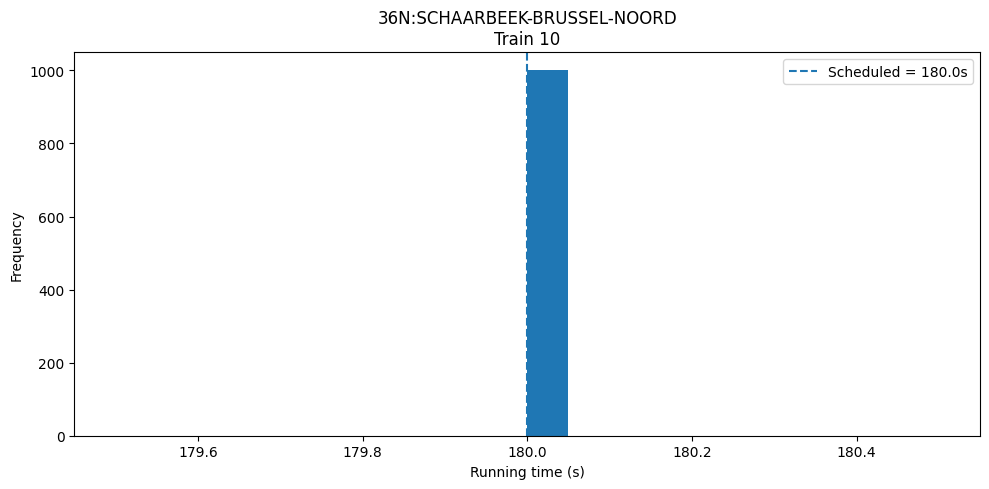

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import logging
logging.basicConfig(level=logging.DEBUG)

import sys
sys.path.insert(0, "/Users/ddw/Desktop/Rescheduling")
from data.loader import load_all
from reality.sampling import sample_running_time
from simulation.simulator import _seconds_to_period

# ============================================================
# Instellingen
# ============================================================

SEGMENT = "36N:SCHAARBEEK-BRUSSEL-NOORD"
N_SAMPLES = 1000
N_FREIGHT = 257
SEED = 42

rng = np.random.default_rng(SEED)

# ============================================================
# Data laden
# ============================================================

trains, segments, timetable = load_all(n_freight=N_FREIGHT)

# ============================================================
# Eén random trein op dit segment kiezen
# ============================================================

candidate_trains = [
    train for train in trains.values()
    if SEGMENT in train.path
]

train = candidate_trains[0]   # veel lichter voor RAM

train_id = train.id
scheduled_rt = timetable.running_time(train_id, SEGMENT)

dynamics = train.dynamics_at(SEGMENT)

entry_time = timetable.scheduled_entry(train_id, SEGMENT)
period = _seconds_to_period(entry_time)

# ============================================================
# Samplen
# ============================================================

samples = []

for _ in range(N_SAMPLES):

    s = sample_running_time(
        section=SEGMENT,
        train_type=("IC", 'S'),
        dynamics=dynamics,
        period=period,
        rng=rng,
    )

    if s is None:
        s = scheduled_rt

    samples.append(s)

samples = np.array(samples)

# ============================================================
# Output
# ============================================================

print(f"Train ID: {train_id}")
print(f"Train type: {train.train_subtype.value}")
print(f"Dynamics: {dynamics}")
print(f"Period: {period}")

print(f"\nScheduled running time: {scheduled_rt:.2f} s")
print(f"Sampled mean:           {samples.mean():.2f} s")
print(f"Sampled median:         {np.median(samples):.2f} s")
print(f"Sampled std:            {samples.std():.2f} s")

# ============================================================
# Plot
# ============================================================

plt.figure(figsize=(10, 5))

plt.hist(samples, bins=20)

plt.axvline(
    scheduled_rt,
    linestyle="--",
    label=f"Scheduled = {scheduled_rt:.1f}s"
)

plt.xlabel("Running time (s)")
plt.ylabel("Frequency")
plt.title(f"{SEGMENT}\nTrain {train_id}")

plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Analyse mismatch tussen geplande rijtijd (timetable)
# en gesamplede werkelijke rijtijd uit de distributies.
#
# Doel:
# - Identificeer segmenten waar de simulator systematisch afwijkt van de timetable
# - Zie waar mediane/verwachte sampled times veel groter of kleiner zijn
# - Handig om te begrijpen waarom MIP-resultaten "te optimistisch" lijken

import pandas as pd
import numpy as np
from data.combine_timetable import combine_timetables
from data.running_distributions import _load

# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

N_FREIGHT = 257   # pas aan indien nodig

# ------------------------------------------------------------
# LOAD TIMETABLE
# ------------------------------------------------------------

df = combine_timetables(N_FREIGHT)

between = df[df["SOURCE"] != df["TARGET"]].copy()

between["PLANNED_RT"] = (
    pd.to_datetime(between["PLANNED_EXIT"])
    - pd.to_datetime(between["PLANNED_ENTRY"])
).dt.total_seconds()

# ------------------------------------------------------------
# GEMIDDELDE geplande rijtijd per combinatie
# ------------------------------------------------------------

planned_lookup = (
    between.groupby(
        ["SECTION", "TRAIN_TYPE", "DYNAMICS", "PERIOD"]
    )["PLANNED_RT"]
    .median()
    .reset_index()
)

# ------------------------------------------------------------
# LOAD DISTRIBUTIONS
# ------------------------------------------------------------

dist = _load()

rows = []

for section, section_data in dist.items():
    for train_type, type_data in section_data.items():
        for dynamics, dyn_data in type_data.items():
            for period, cell in dyn_data.items():

                real_samples = np.array(cell["real"])

                sampled_mean = real_samples.mean()
                sampled_median = np.median(real_samples)
                sampled_std = real_samples.std()

                rows.append({
                    "SECTION": section,
                    "TRAIN_TYPE": train_type,
                    "DYNAMICS": dynamics,
                    "PERIOD": period,
                    "SAMPLED_MEAN": sampled_mean,
                    "SAMPLED_MEDIAN": sampled_median,
                    "SAMPLED_STD": sampled_std,
                    "N_SAMPLES": len(real_samples),
                })

sampled_df = pd.DataFrame(rows)

# ------------------------------------------------------------
# MERGE
# ------------------------------------------------------------

comparison = planned_lookup.merge(
    sampled_df,
    on=["SECTION", "TRAIN_TYPE", "DYNAMICS", "PERIOD"],
    how="inner"
)

# ------------------------------------------------------------
# MISMATCH METRICS
# ------------------------------------------------------------

comparison["ABS_DIFF_MEAN"] = (
    comparison["SAMPLED_MEAN"]
    - comparison["PLANNED_RT"]
)

comparison["ABS_DIFF_MEDIAN"] = (
    comparison["SAMPLED_MEDIAN"]
    - comparison["PLANNED_RT"]
)

comparison["REL_DIFF_MEAN_%"] = (
    100
    * comparison["ABS_DIFF_MEAN"]
    / comparison["PLANNED_RT"]
)

comparison["REL_DIFF_MEDIAN_%"] = (
    100
    * comparison["ABS_DIFF_MEDIAN"]
    / comparison["PLANNED_RT"]
)

comparison["COEFF_VAR"] = (
    comparison["SAMPLED_STD"]
    / comparison["SAMPLED_MEAN"]
)

# ------------------------------------------------------------
# GROOTSTE MISMATCHES
# ------------------------------------------------------------

largest = (
    comparison
    .sort_values("REL_DIFF_MEAN_%", ascending=False)
    .reset_index(drop=True)
)

cols = [
    "SECTION",
    "TRAIN_TYPE",
    "DYNAMICS",
    "PERIOD",
    "PLANNED_RT",
    "SAMPLED_MEAN",
    "SAMPLED_MEDIAN",
    "SAMPLED_STD",
    "REL_DIFF_MEAN_%",
    "REL_DIFF_MEDIAN_%",
    "N_SAMPLES",
]

display(largest[cols].head(50))

# ------------------------------------------------------------
# Samenvatting
# ------------------------------------------------------------

print("=" * 80)
print("ALGEMENE STATISTIEKEN")
print("=" * 80)

print(f"Aantal combinaties: {len(comparison)}")

print("\nGemiddelde relatieve mismatch:")
print(f"{comparison['REL_DIFF_MEAN_%'].mean():.2f}%")

print("\nTop 10 grootste positieve mismatches:")
display(
    largest[cols].head(10)
)

print("\nTop 10 grootste negatieve mismatches:")
display(
    largest.sort_values("REL_DIFF_MEAN_%").head(10)[cols]
)

# ------------------------------------------------------------
# Segmentniveau aggregatie
# ------------------------------------------------------------

segment_summary = (
    comparison.groupby("SECTION")
    .agg({
        "ABS_DIFF_MEAN": "mean",
        "REL_DIFF_MEAN_%": "mean",
        "SAMPLED_STD": "mean",
        "N_SAMPLES": "sum",
    })
    .sort_values("REL_DIFF_MEAN_%", ascending=False)
)

print("\nSegmenten met grootste gemiddelde mismatch:")
display(segment_summary.head(20))

INFO:data.timetable:Gold geladen (passenger): 1028 treinen, 10072 segmenten
INFO:data.timetable:Gold geladen (freight): 257 treinen, 929 segmenten
INFO:data.timetable:Track assignment diagnostics:
  BRUSSEL-CENTRAAL (alle): 965 toewijzingen, 0 capaciteitsconflicten, 0 ongeldige intervallen
  BRUSSEL-CONGRES (alle): 965 toewijzingen, 0 capaciteitsconflicten, 0 ongeldige intervallen
  BRUSSEL-KAPELLEKERK (alle): 965 toewijzingen, 0 capaciteitsconflicten, 0 ongeldige intervallen
INFO:data.combine_timetable:Track assignment diagnostics:
  BRUSSEL-CENTRAAL (alle): 965 toewijzingen, 0 capaciteitsconflicten, 0 ongeldige intervallen
  BRUSSEL-CONGRES (alle): 965 toewijzingen, 0 capaciteitsconflicten, 0 ongeldige intervallen
  BRUSSEL-KAPELLEKERK (alle): 965 toewijzingen, 0 capaciteitsconflicten, 0 ongeldige intervallen
INFO:data.combine_timetable:Gecombineerd: 1285 treinen (1028 passenger, 257 freight), 11001 segmenten


,SECTION,TRAIN_TYPE,DYNAMICS,PERIOD,PLANNED_RT,SAMPLED_MEAN,SAMPLED_MEDIAN,SAMPLED_STD,REL_DIFF_MEAN_%,REL_DIFF_MEDIAN_%,N_SAMPLES
0,0-2:BRUSSEL-CONGRES-BRUSSEL-CENTRAAL,ICE,0-0,EVENING PEAK,59.0,191.493878,161.0,114.579217,224.565894,172.881356,245
1,0-4:BRUSSEL-CONGRES-BRUSSEL-CENTRAAL,L,0-BR,EVENING PEAK,59.0,174.196205,136.0,98.347929,195.247806,130.508475,2161
2,0-3:BRUSSEL-KAPELLEKERK-BRUSSEL-CENTRAAL,L,0-BR,EVENING PEAK,59.0,169.039538,115.0,134.643375,186.507691,94.915254,1644
3,0-2:BRUSSEL-CONGRES-BRUSSEL-CENTRAAL,L,0-BR,EVENING PEAK,59.0,155.360573,109.0,98.070327,163.323005,84.745763,1187
4,0-2:BRUSSEL-CONGRES-BRUSSEL-CENTRAAL,EURST,0-0,MORNING PEAK,59.0,143.630117,112.0,81.122511,143.440876,89.830508,684
5,0-3:BRUSSEL-KAPELLEKERK-BRUSSEL-CENTRAAL,L,0-BR,MORNING PEAK,59.0,141.243355,92.0,93.377264,139.395517,55.932203,1693
6,0-4:BRUSSEL-CONGRES-BRUSSEL-CENTRAAL,L,0-BR,DAYTIME,59.0,140.928231,110.0,67.584141,138.861408,86.440678,5030
7,0-1:BRUSSEL-KAPELLEKERK-BRUSSEL-CENTRAAL,L,0-BR,EVENING PEAK,59.0,134.535593,85.0,93.690364,128.026429,44.067797,1180
8,0-4:BRUSSEL-CONGRES-BRUSSEL-CENTRAAL,L,0-BR,MORNING PEAK,59.0,131.435630,108.0,56.480207,122.772254,83.050847,2206
9,0-4:BRUSSEL-CONGRES-BRUSSEL-CENTRAAL,L,0-BR,EVENING,59.0,127.727813,108.0,47.852412,116.487819,83.050847,2355


ALGEMENE STATISTIEKEN
Aantal combinaties: 658

Gemiddelde relatieve mismatch:
5.98%

Top 10 grootste positieve mismatches:


,SECTION,TRAIN_TYPE,DYNAMICS,PERIOD,PLANNED_RT,SAMPLED_MEAN,SAMPLED_MEDIAN,SAMPLED_STD,REL_DIFF_MEAN_%,REL_DIFF_MEDIAN_%,N_SAMPLES
0,0-2:BRUSSEL-CONGRES-BRUSSEL-CENTRAAL,ICE,0-0,EVENING PEAK,59.0,191.493878,161.0,114.579217,224.565894,172.881356,245
1,0-4:BRUSSEL-CONGRES-BRUSSEL-CENTRAAL,L,0-BR,EVENING PEAK,59.0,174.196205,136.0,98.347929,195.247806,130.508475,2161
2,0-3:BRUSSEL-KAPELLEKERK-BRUSSEL-CENTRAAL,L,0-BR,EVENING PEAK,59.0,169.039538,115.0,134.643375,186.507691,94.915254,1644
3,0-2:BRUSSEL-CONGRES-BRUSSEL-CENTRAAL,L,0-BR,EVENING PEAK,59.0,155.360573,109.0,98.070327,163.323005,84.745763,1187
4,0-2:BRUSSEL-CONGRES-BRUSSEL-CENTRAAL,EURST,0-0,MORNING PEAK,59.0,143.630117,112.0,81.122511,143.440876,89.830508,684
5,0-3:BRUSSEL-KAPELLEKERK-BRUSSEL-CENTRAAL,L,0-BR,MORNING PEAK,59.0,141.243355,92.0,93.377264,139.395517,55.932203,1693
6,0-4:BRUSSEL-CONGRES-BRUSSEL-CENTRAAL,L,0-BR,DAYTIME,59.0,140.928231,110.0,67.584141,138.861408,86.440678,5030
7,0-1:BRUSSEL-KAPELLEKERK-BRUSSEL-CENTRAAL,L,0-BR,EVENING PEAK,59.0,134.535593,85.0,93.690364,128.026429,44.067797,1180
8,0-4:BRUSSEL-CONGRES-BRUSSEL-CENTRAAL,L,0-BR,MORNING PEAK,59.0,131.435630,108.0,56.480207,122.772254,83.050847,2206
9,0-4:BRUSSEL-CONGRES-BRUSSEL-CENTRAAL,L,0-BR,EVENING,59.0,127.727813,108.0,47.852412,116.487819,83.050847,2355



Top 10 grootste negatieve mismatches:


,SECTION,TRAIN_TYPE,DYNAMICS,PERIOD,PLANNED_RT,SAMPLED_MEAN,SAMPLED_MEDIAN,SAMPLED_STD,REL_DIFF_MEAN_%,REL_DIFF_MEDIAN_%,N_SAMPLES
657,0-6:BRUSSEL-CENTRAAL-BRUSSEL-KAPELLEKERK,IC,ACC-0,DAYTIME,120.0,62.752044,62.0,7.210942,-47.706630,-48.333333,6727
656,0-6:BRUSSEL-CENTRAAL-BRUSSEL-KAPELLEKERK,IC,ACC-0,EVENING PEAK,120.0,62.752288,62.0,8.324667,-47.706427,-48.333333,3060
655,0-6:BRUSSEL-CENTRAAL-BRUSSEL-KAPELLEKERK,IC,ACC-0,NIGHT,120.0,62.927622,62.0,6.460361,-47.560315,-48.333333,677
654,0-6:BRUSSEL-CENTRAAL-BRUSSEL-KAPELLEKERK,IC,ACC-0,MORNING PEAK,120.0,62.980579,63.0,6.765578,-47.516184,-47.500000,2935
653,28(1):THURN EN TAXIS-SIMONIS,L,0-0,EVENING PEAK,179.0,93.987013,95.0,7.175433,-47.493289,-46.927374,308
652,28(1):THURN EN TAXIS-SIMONIS,L,0-0,DAYTIME,179.0,94.550355,95.0,4.792201,-47.178573,-46.927374,705
651,28(1):THURN EN TAXIS-SIMONIS,L,0-0,NIGHT,179.0,94.750000,95.0,4.444825,-47.067039,-46.927374,116
650,0-6:BRUSSEL-CENTRAAL-BRUSSEL-KAPELLEKERK,IC,ACC-0,EVENING,120.0,63.654916,63.0,11.082154,-46.954237,-47.500000,4567
649,0-2:BRUSSEL-CENTRAAL-BRUSSEL-KAPELLEKERK,IC,ACC-0,NIGHT,120.0,65.428781,65.0,5.737119,-45.476016,-45.833333,1362
648,0-2:BRUSSEL-CENTRAAL-BRUSSEL-KAPELLEKERK,ICE,0-0,EVENING,119.0,65.461157,61.0,17.321574,-44.990624,-48.739496,605



Segmenten met grootste gemiddelde mismatch:


,ABS_DIFF_MEAN,REL_DIFF_MEAN_%,SAMPLED_STD,N_SAMPLES
SECTION,,,,
0-4:BRUSSEL-CONGRES-BRUSSEL-CENTRAAL,42.787165,65.490803,57.533472,44458
0-3:BRUSSEL-KAPELLEKERK-BRUSSEL-CENTRAAL,35.238480,59.172875,78.105855,40812
0-2:BRUSSEL-CONGRES-BRUSSEL-CENTRAAL,34.122112,54.237991,66.131220,47649
0-1:BRUSSEL-KAPELLEKERK-BRUSSEL-CENTRAAL,26.785476,45.927459,64.295488,46072
0-6:BRUSSEL-NOORD-BRUSSEL-CONGRES,29.080089,37.392721,12.766168,23942
0-5:BRUSSEL-ZUID-BRUSSEL-KAPELLEKERK,23.625287,27.466681,21.955391,14048
0-2:BRUSSEL-KAPELLEKERK-BRUSSEL-ZUID,28.053160,25.614584,64.912193,47669
28(1):BRUSSEL-WEST-SIMONIS,13.782863,23.485147,9.180334,2679
36N:BRUSSEL-NOORD-BOCKSTAEL,55.076923,22.948718,60.035197,13


In [ ]:
"""
Notebook-cell script: check of er treinen zijn waarvan het laatste segment
een dwell-segment is na `run_simulation(...)`.

Gebruik in notebook:

    # na run_simulation
    # state, df, meta, config_dir, simulator = run_simulation(...)
    exec(open("notebooks/cells/check_last_segment_dwell.py").read())

Vereist in de notebook namespace:
    - trains (dict[int, Train])
"""

import pandas as pd

if "trains" not in globals():
    raise RuntimeError(
        "Variable 'trains' niet gevonden. Zorg dat je eerst data laadt, "
        "bv: trains, segments, timetable = load_all(...)."
    )

rows = []
for train_id, train in sorted(trains.items()):
    last_seg = train.last_segment
    is_dwell_last = bool(train.halts_at(last_seg))
    rows.append(
        {
            "train_id": int(train_id),
            "last_segment": last_seg,
            "last_segment_is_dwell": is_dwell_last,
            "n_segments": len(train.path),
        }
    )

df_last_segment_dwell = pd.DataFrame(rows)

df_last_segment_dwell_true = (
    df_last_segment_dwell[df_last_segment_dwell["last_segment_is_dwell"]]
    .sort_values("train_id")
    .reset_index(drop=True)
)

print(
    f"Treinen met laatste segment als dwell: "
    f"{len(df_last_segment_dwell_true)} / {len(df_last_segment_dwell)}"
)

# In notebook: direct zichtbaar
try:
    display(df_last_segment_dwell_true)
except NameError:
    # Buiten notebook fallback
    print(df_last_segment_dwell_true.head(20).to_string(index=False))

Treinen met laatste segment als dwell: 0 / 1285


,train_id,last_segment,last_segment_is_dwell,n_segments


In [ ]:
from utils.queue_diagnostics import segment_queue_overlaps, solver_change_log
from config.settings import RESULTS_DIR
import pandas

# 1) Waar was overlap / queue pressure?
overlaps = segment_queue_overlaps(df)
display(overlaps.head(30))

# Eventueel samenvatting per segment:
display(
    overlaps.groupby("segment_id", as_index=False)
    .agg(
        n_overlaps=("segment_id", "size"),
        total_overlap_s=("overlap_seconds", "sum"),
        max_overlap_s=("overlap_seconds", "max"),
    )
    .sort_values(["total_overlap_s", "n_overlaps"], ascending=False)
)

# 2) Wat heeft solver aangepast per reschedule?
changes = solver_change_log(simulator)
display(changes.head(50))

# Focus op echte tijdswijzigingen:
changed_only = changes[
    changes["entry_delta"].fillna(0).abs().gt(1e-9) |
    changes["exit_delta"].fillna(0).abs().gt(1e-9)
].copy()
display(changed_only.head(100))
overlaps.to_csv(RESULTS_DIR / "segment_overlaps.csv", index=False)
changes.to_csv(RESULTS_DIR / "solver_changes.csv", index=False)
excel_path = RESULTS_DIR / "queue_diagnostics.xlsx"

with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    overlaps.to_excel(writer, sheet_name="overlaps", index=False)
    changes.to_excel(writer, sheet_name="solver_changes", index=False)

ValueError: Missing columns in df: ['actual_entry', 'actual_exit', 'segment_id', 'train_id']

In [ ]:
# 1. Geven de draaiende treinen hun segmenten netjes vrij? Check eindbezetting:
occupied_now = {s: t for s, t in simulator._dispatcher._occupied.items() if t is not None}
print(f"Segmenten nog bezet aan einde sim: {len(occupied_now)}")
for s, t in list(occupied_now.items())[:20]:
    print(f"  {s!r} bezet door trein {t}")

# 2. Van de 1048 niet-gestarte treinen: delen ze hun eerste segment met EEN
#    van de bezet-gebleven segmenten? (= achter een vastzittende trein)
not_started = [t for t in trains if not state._actual.get(t)]
stuck_segs = set(occupied_now.keys())
blocked_behind = [t for t in not_started if trains[t].first_segment in stuck_segs]
print(f"\nNiet-gestart EN eerste segment is nog bezet: {len(blocked_behind)} / {len(not_started)}")

# 3. KRITIEK: hoeveel treinen zijn 'finished'? En hoeveel hangen halverwege?
finished = [t for t in trains if state.is_finished(t)]
active_end = state.active_train_ids()
print(f"\nfinished: {len(finished)}")
print(f"actief aan einde (gestart, niet af): {len(active_end)}")
print(f"nooit gestart: {len(not_started)}")
print(f"som: {len(finished) + len(active_end) + len(not_started)} (moet {len(trains)} zijn)")

# 4. Van de 160 die draaiden: hoeveel zijn ECHT finished vs hangen vast?
ran = [t for t in trains if state._actual.get(t)]
ran_finished = [t for t in ran if state.is_finished(t)]
print(f"\nvan {len(ran)} gedraaide treinen: {len(ran_finished)} finished, {len(ran)-len(ran_finished)} hangen halverwege")

Segmenten nog bezet aan einde sim: 0

Niet-gestart EN eerste segment is nog bezet: 0 / 0

finished: 1210
actief aan einde (gestart, niet af): 0
nooit gestart: 0
som: 1210 (moet 1210 zijn)

van 1210 gedraaide treinen: 1210 finished, 0 hangen halverwege


In [ ]:
import pandas as pd

# 1. Welke treinen waren al klaar vóór de eerste MIP?
FIRST_MIP_T = 50037

last_seg = (
    df.sort_values('planned_entry')
      .groupby(['train_id', 'train_type'])
      .last()
      .reset_index()
)

before  = last_seg[last_seg['actual_exit'] <  FIRST_MIP_T]
after   = last_seg[last_seg['actual_exit'] >= FIRST_MIP_T]

ted_before = before['entry_delay'].clip(lower=0).sum()
ted_after  = after['entry_delay'].clip(lower=0).sum()

print(f"TED van treinen klaar VOOR  t={FIRST_MIP_T}: {ted_before:.0f}  (n={len(before)})")
print(f"TED van treinen klaar NA    t={FIRST_MIP_T}: {ted_after:.0f}   (n={len(after)})")
print(f"Som = {ted_before+ted_after:.0f}, totale TED = {last_seg['entry_delay'].clip(lower=0).sum():.0f}")

TED van treinen klaar VOOR  t=50037: 26215  (n=615)
TED van treinen klaar NA    t=50037: 27707   (n=595)
Som = 53921, totale TED = 53921


In [ ]:
# 1. Heeft de trein überhaupt iets in _actual?
print("actual dict:", state._actual.get(900000))
print("current_segment:", state._current_segment.get(900000))
print("is_finished:", state.is_finished(900000))
print("remaining_path:", state.remaining_path(900000))

# 2. Stond er een TrainEntered voor 900000 in de queue, en is de sim er voorbij?
print("eindtijd simulatie:", state.current_time)
print("eerste scheduled_entry 900000:", timetable.scheduled_entry(900000, trains[900000].path[0]))

# 3. Hoeveel treinen hebben WEL gedraaid? Staat 900000 echt in de geladen set?
print("900000 in trains:", 900000 in trains)
ran = [t for t in trains if state._actual.get(t)]
print(f"treinen met geregistreerde activiteit: {len(ran)} / {len(trains)}")
not_started = [t for t in trains if not state._actual.get(t)]
print(f"treinen die nooit startten: {len(not_started)}")
print("voorbeelden niet-gestart:", not_started[:10])

actual dict: {'28(1):BRUSSEL-ZUID-BRUSSEL-WEST': (40241.0, 40663.5), 'BRUSSEL-WEST -- platform 1': (40663.5, 40664.5), '28(1):BRUSSEL-WEST-SIMONIS': (40664.5, 40754.2), 'SIMONIS -- platform 1': (40754.2, 40755.2), '28(1):SIMONIS-THURN EN TAXIS': (40755.2, 40877.399999999994), 'THURN EN TAXIS -- platform 1': (40877.399999999994, 40878.399999999994), '28:THURN EN TAXIS-SCHAARBEEK': (40878.399999999994, 41292.399999999994), 'SCHAARBEEK -- T2b': (41292.399999999994, 41293.399999999994), '36N:SCHAARBEEK-BRUSSEL-NOORD': (41293.399999999994, 41661.3)}
current_segment: None
is_finished: True
remaining_path: []
eindtijd simulatie: 87009.0
eerste scheduled_entry 900000: 40241.0
900000 in trains: True
treinen met geregistreerde activiteit: 1210 / 1210
treinen die nooit startten: 0
voorbeelden niet-gestart: []


In [ ]:
# A. Delen veel treinen hetzelfde eerste segment? (gedeelde-bezetting hypothese)
from collections import Counter
first_segs = Counter(trains[t].first_segment for t in trains)
print("Top 10 meest-gedeelde eerste segmenten:")
for seg, cnt in first_segs.most_common(10):
    print(f"  {cnt:4d} treinen starten op  {seg}")

# B. Van de 150 die WEL draaiden — wat is hun eerste segment, en hoe laat startten ze?
ran = [t for t in trains if state._actual.get(t)]
print(f"\n{len(ran)} treinen draaiden. Hun start-tijden:")
start_times = sorted(
    state.actual_entry(t, trains[t].first_segment) for t in ran
)
print(f"  vroegste start: {start_times[0]:.0f}s")
print(f"  laatste start:  {start_times[-1]:.0f}s")

# C. Bestaat het eerste segment van 900000 wel in de segments-dict / dispatcher?
t0 = trains[900000].first_segment
print(f"\n900000 first_segment: {t0!r}")
print(f"  in segments dict: {t0 in segments}")

# D. Hoeveel events zaten er nog in de queue toen de sim 'klaar' was?
#    (al leeg, maar: hoeveel stale-skips? voeg desnoods een counter toe)

Top 10 meest-gedeelde eerste segmenten:
   193 treinen starten op  36N:SCHAARBEEK-BRUSSEL-NOORD
   158 treinen starten op  0-1:BRUSSEL-ZUID-BRUSSEL-KAPELLEKERK
   107 treinen starten op  0-3:BRUSSEL-ZUID-BRUSSEL-KAPELLEKERK
    99 treinen starten op  25:SCHAARBEEK-BRUSSEL-NOORD
    92 treinen starten op  36:SCHAARBEEK-BRUSSEL-NOORD
    88 treinen starten op  50C:ANDERLECHT-BRUSSEL-ZUID
    70 treinen starten op  161:BRUSSEL-SCHUMAN-BRUSSEL-NOORD
    67 treinen starten op  25:BRUSSEL-NOORD-SCHAARBEEK
    65 treinen starten op  0-5:BRUSSEL-ZUID-BRUSSEL-KAPELLEKERK
    65 treinen starten op  124:VORST-OOST-BRUSSEL-ZUID

1210 treinen draaiden. Hun start-tijden:
  vroegste start: 0s
  laatste start:  86220s

900000 first_segment: '28(1):BRUSSEL-ZUID-BRUSSEL-WEST'
  in segments dict: True


In [ ]:
import pandas as pd

rows = []

for train_id, train in trains.items():

    max_delay = 0
    worst_segment = None
    planned_exit_worst = None
    actual_exit_worst = None

    for seg in train.path:

        try:
            actual_exit = state.actual_exit(train_id, seg)
        except KeyError:
            continue

        planned_exit = timetable.scheduled_exit(train_id, seg)

        delay = actual_exit - planned_exit

        if delay > max_delay:
            max_delay = delay
            worst_segment = seg
            planned_exit_worst = planned_exit
            actual_exit_worst = actual_exit

    rows.append({
        "train_id": train_id,
        "train_type": train.train_type.value,
        "max_delay_sec": round(max_delay, 1),
        "max_delay_min": round(max_delay / 60, 2),
        "worst_segment": worst_segment,
        "planned_exit": planned_exit_worst,
        "actual_exit": actual_exit_worst,
    })

df_worst_actual = (
    pd.DataFrame(rows)
    .sort_values("max_delay_sec", ascending=False)
    .reset_index(drop=True)
)

display(df_worst_actual.head(20))

,train_id,train_type,max_delay_sec,max_delay_min,worst_segment,planned_exit,actual_exit
0,900179,F,1505.4,25.09,36N:SCHAARBEEK-BRUSSEL-NOORD,74884.0,76389.4
1,900155,F,1258.6,20.98,36N:SCHAARBEEK-BRUSSEL-NOORD,75634.0,76892.6
2,2088,P,621.4,10.36,BRUSSEL-KAPELLEKERK -- platform 4 -- platform 4,67981.0,68602.4
3,1538,P,598.0,9.97,BRUSSEL-CENTRAAL -- platform 4 -- platform 4,62280.0,62878.0
4,900079,F,577.0,9.62,36N:SCHAARBEEK-BRUSSEL-NOORD,2998.0,3575.0
5,442,P,544.6,9.08,36N:SCHAARBEEK-BRUSSEL-NOORD,76740.0,77284.6
6,2138,P,543.0,9.05,0-6:BRUSSEL-KAPELLEKERK-BRUSSEL-ZUID,66360.0,66903.0
7,3689,P,542.0,9.03,BRUSSEL-KAPELLEKERK -- platform 1 -- platform 1,66361.0,66903.0
8,1955,P,492.4,8.21,BRUSSEL-NOORD -- platform 12 -- platform 12,24420.0,24912.4
9,900168,F,490.1,8.17,36N:SCHAARBEEK-BRUSSEL-NOORD,2197.0,2687.1


DEBUG:matplotlib:matplotlib data path: /Users/ddw/Desktop/Rescheduling/venv/lib/python3.13/site-packages/matplotlib/mpl-data
DEBUG:matplotlib:CONFIGDIR=/Users/ddw/.matplotlib
DEBUG:matplotlib:interactive is False
DEBUG:matplotlib:platform is darwin
DEBUG:matplotlib:CACHEDIR=/Users/ddw/.matplotlib
DEBUG:matplotlib.font_manager:Using fontManager instance from /Users/ddw/.matplotlib/fontlist-v390.json



GLOBAL SUMMARY
Total segment decisions: 15
Average absolute shift: 0.26 min
Median absolute shift: 0.15 min
Maximum shift: 0.82 min
95th percentile shift: 0.62 min

TRAINS WITH LARGEST TOTAL RESCHEDULING


,train_id,train_type,avg_shift_min,max_shift_min,total_shift_min,n_changed_segments,n_segments,share_changed
1,2045,P,0.319048,0.533333,2.233333,7,7,1.000000
3,3144,P,0.816667,0.816667,0.816667,1,1,1.000000
0,1945,P,0.125000,0.500000,0.500000,1,4,0.250000
2,3123,P,0.100000,0.150000,0.300000,2,3,0.666667



MOST IMPACTED SEGMENTS


,segment,avg_shift_min,max_shift_min,total_shift_min,affected_trains
5,0-6:BRUSSEL-KAPELLEKERK-BRUSSEL-ZUID,0.816667,0.816667,0.816667,1
0,0-4:BRUSSEL-CENTRAAL-BRUSSEL-KAPELLEKERK,0.266667,0.533333,0.533333,2
2,0-4:BRUSSEL-KAPELLEKERK-BRUSSEL-ZUID,0.266667,0.533333,0.533333,2
7,BRUSSEL-CENTRAAL -- platform 5 -- platform 6,0.533333,0.533333,0.533333,1
10,BRUSSEL-KAPELLEKERK -- platform 1 -- platform 1,0.533333,0.533333,0.533333,1
8,BRUSSEL-CENTRAAL -- platform 6 -- platform 5,0.500000,0.500000,0.500000,1
4,0-5:BRUSSEL-CONGRES-BRUSSEL-NOORD,0.150000,0.150000,0.150000,1
12,BRUSSEL-NOORD -- platform 10 -- platform 10,0.150000,0.150000,0.150000,1
1,0-4:BRUSSEL-CONGRES-BRUSSEL-CENTRAAL,0.033333,0.033333,0.033333,1
3,0-4:BRUSSEL-NOORD-BRUSSEL-CONGRES,0.033333,0.033333,0.033333,1


...


MOST EXTREME SINGLE SEGMENT MODIFICATIONS


,train_id,train_type,segment,entry_shift_min,exit_shift_min,abs_shift_min
14,3144,P,0-6:BRUSSEL-KAPELLEKERK-BRUSSEL-ZUID,-0.800000,-0.816667,0.816667
7,2045,P,BRUSSEL-CENTRAAL -- platform 5 -- platform 6,0.033333,0.533333,0.533333
8,2045,P,0-4:BRUSSEL-CENTRAAL-BRUSSEL-KAPELLEKERK,0.533333,0.533333,0.533333
9,2045,P,BRUSSEL-KAPELLEKERK -- platform 1 -- platform 1,0.533333,0.533333,0.533333
10,2045,P,0-4:BRUSSEL-KAPELLEKERK-BRUSSEL-ZUID,0.533333,0.533333,0.533333
0,1945,P,BRUSSEL-CENTRAAL -- platform 6 -- platform 5,-0.500000,0.000000,0.500000
11,3123,P,0-5:BRUSSEL-CONGRES-BRUSSEL-NOORD,0.033333,0.150000,0.150000
12,3123,P,BRUSSEL-NOORD -- platform 10 -- platform 10,0.150000,0.000000,0.150000
4,2045,P,0-4:BRUSSEL-NOORD-BRUSSEL-CONGRES,0.000000,0.033333,0.033333
5,2045,P,BRUSSEL-CONGRES -- platform 3 -- platform 3,0.033333,0.033333,0.033333


DEBUG:matplotlib.pyplot:Loaded backend module://matplotlib_inline.backend_inline version unknown.
DEBUG:matplotlib.pyplot:Loaded backend module://matplotlib_inline.backend_inline version unknown.
DEBUG:matplotlib.font_manager:findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0.
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/Users/ddw/Desktop/Rescheduling/venv/lib/python3.13/site-packages/matplotlib/mpl-data/fonts/ttf/STIXSizFourSymBol.ttf', name='STIXSizeFourSym', style='normal', variant='normal', weight=700, stretch='normal', size='scalable')) = 10.335
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/Users/ddw/Desktop/Rescheduling/venv/lib/python3.13/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSans-Bold.ttf', name='DejaVu Sans', style='normal', variant='normal', weight=700, stretch='normal', size='scalable')) = 0.33499999999999996
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/Users/dd


SCHEDULE STABILITY ANALYSIS
Changed segment decisions : 11
Share changed             : 73.33%
Changes > 5 min           : 0
Changes > 15 min          : 0


DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/System/Library/Fonts/Supplemental/InaiMathi-MN.ttc', name='InaiMathi', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/System/Library/Fonts/SFArabic.ttf', name='.SF Arabic', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/System/Library/Fonts/Supplemental/SnellRoundhand.ttc', name='Snell Roundhand', style='normal', variant='normal', weight=500, stretch='normal', size='scalable')) = 10.145
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/System/Library/AssetsV2/com_apple_MobileAsset_Font7/de97612eef4e3cf8ee8e5c0ebd6fd879bbecd23a.asset/AssetData/AppleLiGothic-Medium.ttf', name='Apple LiGothic', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
DEBUG:matplotlib.fo

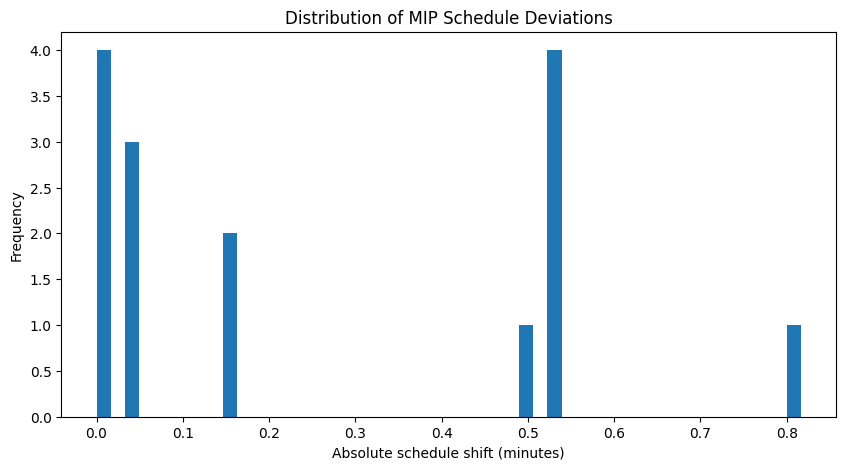

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


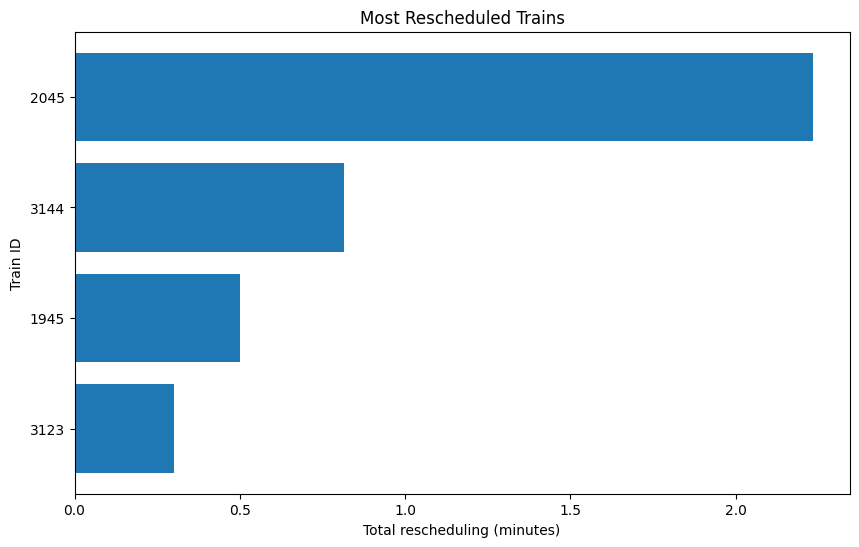


OBJECTIVE INFO
Objective value : 32.0
Runtime          : 0.00 sec

EVOLUTION OF SUCCESSIVE RESCHEDULES


,iteration,objective,avg_shift_min,max_shift_min,total_shift_min
0,0,856.0,0.425164,2.350000,64.625000
1,1,1957.6,0.318801,6.001667,46.545000
2,2,1461.2,0.452218,7.601667,61.501667
3,3,785.1,0.337528,1.900000,49.616667
4,4,1246.0,0.352201,3.050000,46.138333
...,...,...,...,...,...
89,89,546.0,0.618758,5.500000,152.833333
90,90,732.2,0.782580,5.500000,138.516667
91,91,265.0,0.645126,3.500000,68.383333
92,92,147.2,0.363258,3.500000,15.983333


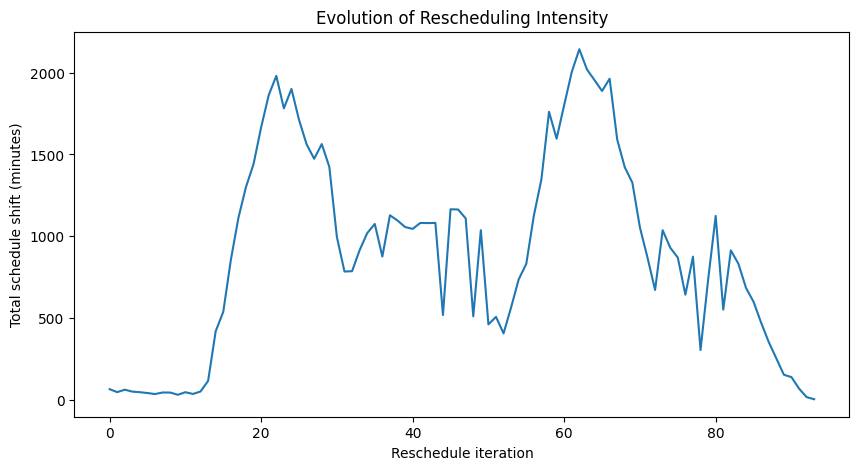

In [ ]:
# ============================================================
# COMPREHENSIVE MIP SCHEDULE ANALYSIS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# CHECK
# ============================================================

if not hasattr(simulator, "_solutions"):
    raise ValueError(
        "simulator._solutions bestaat niet. "
        "Heb je optie 3 correct toegevoegd?"
    )

if len(simulator._solutions) == 0:
    raise ValueError(
        "Geen MIP-solutions opgeslagen in simulator._solutions"
    )


# ============================================================
# SELECT SOLUTION
# ============================================================

# Laatste oplossing
solution = simulator._solutions[-1]

# Of:
# solution = simulator._solutions[0]
# solution = simulator._solutions[i]


# ============================================================
# BUILD SEGMENT-LEVEL ANALYSIS TABLE
# ============================================================

rows = []

for train_id, train in trains.items():

    for seg in train.path:

        planned_entry = timetable.scheduled_entry(train_id, seg)
        planned_exit  = timetable.scheduled_exit(train_id, seg)

        mip_entry = solution.entry.get((train_id, seg))
        mip_exit  = solution.exit.get((train_id, seg))

        if mip_entry is None or mip_exit is None:
            continue

        entry_shift = mip_entry - planned_entry
        exit_shift  = mip_exit  - planned_exit

        abs_shift = max(
            abs(entry_shift),
            abs(exit_shift),
        )

        rows.append({
            "train_id": train_id,
            "train_type": train.train_type.value,
            "segment": seg,

            "planned_entry": planned_entry,
            "mip_entry": mip_entry,

            "planned_exit": planned_exit,
            "mip_exit": mip_exit,

            "entry_shift_sec": entry_shift,
            "exit_shift_sec": exit_shift,

            "entry_shift_min": entry_shift / 60,
            "exit_shift_min": exit_shift / 60,

            "abs_shift_sec": abs_shift,
            "abs_shift_min": abs_shift / 60,
        })

df_schedule = pd.DataFrame(rows)


# ============================================================
# GLOBAL SUMMARY
# ============================================================

print("\n==================================================")
print("GLOBAL SUMMARY")
print("==================================================")

print(f"Total segment decisions: {len(df_schedule):,}")

print(
    f"Average absolute shift: "
    f"{df_schedule['abs_shift_min'].mean():.2f} min"
)

print(
    f"Median absolute shift: "
    f"{df_schedule['abs_shift_min'].median():.2f} min"
)

print(
    f"Maximum shift: "
    f"{df_schedule['abs_shift_min'].max():.2f} min"
)

print(
    f"95th percentile shift: "
    f"{df_schedule['abs_shift_min'].quantile(0.95):.2f} min"
)


# ============================================================
# MOST RESCHEDULED TRAINS
# ============================================================

train_summary = (
    df_schedule
    .groupby("train_id")
    .agg(
        train_type=("train_type", "first"),

        avg_shift_min=("abs_shift_min", "mean"),
        max_shift_min=("abs_shift_min", "max"),

        total_shift_min=("abs_shift_min", "sum"),

        n_changed_segments=(
            "abs_shift_sec",
            lambda x: (x > 1).sum()
        ),

        n_segments=("segment", "count"),
    )
    .reset_index()
)

train_summary["share_changed"] = (
    train_summary["n_changed_segments"]
    / train_summary["n_segments"]
)

train_summary = train_summary.sort_values(
    "total_shift_min",
    ascending=False,
)

print("\n==================================================")
print("TRAINS WITH LARGEST TOTAL RESCHEDULING")
print("==================================================")

display(train_summary.head(20))


# ============================================================
# MOST MODIFIED SEGMENTS
# ============================================================

segment_summary = (
    df_schedule
    .groupby("segment")
    .agg(
        avg_shift_min=("abs_shift_min", "mean"),
        max_shift_min=("abs_shift_min", "max"),
        total_shift_min=("abs_shift_min", "sum"),
        affected_trains=("train_id", "nunique"),
    )
    .reset_index()
)

segment_summary = segment_summary.sort_values(
    "total_shift_min",
    ascending=False,
)

print("\n==================================================")
print("MOST IMPACTED SEGMENTS")
print("==================================================")

display(segment_summary.head(20))


# ============================================================
# PASSENGER VS FREIGHT
# ============================================================

type_summary = (
    df_schedule
    .groupby("train_type")
    .agg(
        avg_shift_min=("abs_shift_min", "mean"),
        median_shift_min=("abs_shift_min", "median"),
        max_shift_min=("abs_shift_min", "max"),
        total_shift_min=("abs_shift_min", "sum"),
        n_segments=("segment", "count"),
    )
)

print("\n==================================================")
print("PASSENGER VS FREIGHT")
print("==================================================")

display(type_summary)


# ============================================================
# MOST EXTREME MODIFICATIONS
# ============================================================

extreme_changes = (
    df_schedule
    .sort_values("abs_shift_sec", ascending=False)
)

print("\n==================================================")
print("MOST EXTREME SINGLE SEGMENT MODIFICATIONS")
print("==================================================")

display(
    extreme_changes[
        [
            "train_id",
            "train_type",
            "segment",
            "entry_shift_min",
            "exit_shift_min",
            "abs_shift_min",
        ]
    ].head(30)
)


# ============================================================
# STABILITY / NERVOUSNESS ANALYSIS
# ============================================================

print("\n==================================================")
print("SCHEDULE STABILITY ANALYSIS")
print("==================================================")

n_changed = (df_schedule["abs_shift_sec"] > 1).sum()

share_changed = n_changed / len(df_schedule)

print(f"Changed segment decisions : {n_changed:,}")
print(f"Share changed             : {share_changed:.2%}")

large_changes = (df_schedule["abs_shift_min"] > 5).sum()

print(f"Changes > 5 min           : {large_changes:,}")

very_large_changes = (df_schedule["abs_shift_min"] > 15).sum()

print(f"Changes > 15 min          : {very_large_changes:,}")


# ============================================================
# HISTOGRAM OF SHIFTS
# ============================================================

plt.figure(figsize=(10, 5))

plt.hist(
    df_schedule["abs_shift_min"],
    bins=50,
)

plt.xlabel("Absolute schedule shift (minutes)")
plt.ylabel("Frequency")
plt.title("Distribution of MIP Schedule Deviations")

plt.show()


# ============================================================
# TOP 10 RESCHEDULED TRAINS VISUALIZATION
# ============================================================

top_trains = (
    train_summary
    .head(10)
    .sort_values("total_shift_min")
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_trains["train_id"].astype(str),
    top_trains["total_shift_min"],
)

plt.xlabel("Total rescheduling (minutes)")
plt.ylabel("Train ID")
plt.title("Most Rescheduled Trains")

plt.show()


# ============================================================
# OBJECTIVE INFO
# ============================================================

print("\n==================================================")
print("OBJECTIVE INFO")
print("==================================================")

if hasattr(solution, "objective"):
    print(f"Objective value : {solution.objective}")

if hasattr(solution, "runtime"):
    print(f"Runtime          : {solution.runtime:.2f} sec")

if hasattr(solution, "gap"):
    print(f"MIP gap          : {solution.gap:.4f}")


# ============================================================
# MULTI-SOLUTION EVOLUTION ANALYSIS
# ============================================================

if len(simulator._solutions) > 1:

    rows = []

    for i, sol in enumerate(simulator._solutions):

        shifts = []

        for (t, seg), arr in sol.entry.items():

            planned = timetable.scheduled_entry(t, seg)

            shifts.append(abs(arr - planned) / 60)

        rows.append({
            "iteration": i,
            "objective": getattr(sol, "objective", np.nan),
            "avg_shift_min": np.mean(shifts),
            "max_shift_min": np.max(shifts),
            "total_shift_min": np.sum(shifts),
        })

    df_evolution = pd.DataFrame(rows)

    print("\n==================================================")
    print("EVOLUTION OF SUCCESSIVE RESCHEDULES")
    print("==================================================")

    display(df_evolution)

    plt.figure(figsize=(10, 5))

    plt.plot(
        df_evolution["iteration"],
        df_evolution["total_shift_min"],
    )

    plt.xlabel("Reschedule iteration")
    plt.ylabel("Total schedule shift (minutes)")
    plt.title("Evolution of Rescheduling Intensity")

    plt.show()


# ============================================================
# OPTIONAL EXPORT
# ============================================================

# df_schedule.to_csv("schedule_analysis.csv", index=False)
# train_summary.to_csv("train_summary.csv", index=False)
# segment_summary.to_csv("segment_summary.csv", index=False)

In [ ]:
# ============================================================
# COMPARE RESCHEDULED TIMES VS ORIGINAL TIMETABLE
# ============================================================
#
# Geeft voor elk herscheduled segment:
#   - originele timetable tijden
#   - rescheduled tijden
#   - vertragingen
#
# Werkt op:
#   solution.arrival
#   solution.departure
#
# ============================================================

import pandas as pd

# ============================================================
# BUILD COMPARISON TABLE
# ============================================================

rows = []

for (train_id, segment_id), new_entry in solution.entry.items():

    new_exit = solution.exit.get((train_id, segment_id))

    # originele timetable
    planned_entry = timetable.scheduled_entry(train_id, segment_id)
    planned_exit  = timetable.scheduled_exit(train_id, segment_id)

    rows.append({

        "TRAIN_NO": train_id,
        "SECTION": segment_id,

        # ORIGINAL
        "planned_entry": planned_entry,
        "planned_exit": planned_exit,

        # RESCHEDULED
        "rescheduled_entry": new_entry,
        "rescheduled_exit": new_exit,

        # DELAYS
        "entry_delay": (
            new_entry - planned_entry
            if new_entry is not None else None
        ),

        "exit_delay": (
            new_exit - planned_exit
            if new_exit is not None else None
        ),

        # RUNNING TIMES
        "planned_runtime": (
            planned_exit - planned_entry
        ),

        "rescheduled_runtime": (
            new_exit - new_entry
            if new_exit is not None else None
        ),

    })

comparison = pd.DataFrame(rows)

# ============================================================
# SORT
# ============================================================

comparison = comparison.sort_values(
    ["TRAIN_NO", "rescheduled_entry"]
).reset_index(drop=True)

# ============================================================
# DISPLAY
# ============================================================

pd.set_option("display.max_rows", 500)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 250)

display(comparison)

# ============================================================
# MOST DELAYED
# ============================================================

print("\n" + "=" * 100)
print("MOST DELAYED SEGMENTS")
print("=" * 100)

display(
    comparison.sort_values(
        "exit_delay",
        ascending=False
    ).head(50)
)

# ============================================================
# CHANGED RUNNING TIMES
# ============================================================

comparison["runtime_diff"] = (
    comparison["rescheduled_runtime"] -
    comparison["planned_runtime"]
)

print("\n" + "=" * 100)
print("BIGGEST RUNTIME CHANGES")
print("=" * 100)

display(
    comparison.sort_values(
        "runtime_diff",
        ascending=False
    ).head(50)
)

,TRAIN_NO,SECTION,planned_entry,planned_exit,rescheduled_entry,rescheduled_exit,entry_delay,exit_delay,planned_runtime,rescheduled_runtime
0,1945,BRUSSEL-CENTRAAL -- platform 6 -- platform 5,86580.0,86640.0,86550.0,86640.0,-30.0,0.0,60.0,90.0
1,1945,0-4:BRUSSEL-CENTRAAL-BRUSSEL-KAPELLEKERK,86640.0,86760.0,86640.0,86760.0,0.0,0.0,120.0,120.0
2,1945,BRUSSEL-KAPELLEKERK -- platform 3 -- platform 3,86760.0,86761.0,86760.0,86761.0,0.0,0.0,1.0,1.0
3,1945,0-4:BRUSSEL-KAPELLEKERK-BRUSSEL-ZUID,86761.0,86880.0,86761.0,86880.0,0.0,0.0,119.0,119.0
4,2045,0-4:BRUSSEL-NOORD-BRUSSEL-CONGRES,86520.0,86640.0,86520.0,86642.0,0.0,2.0,120.0,122.0
5,2045,BRUSSEL-CONGRES -- platform 3 -- platform 3,86640.0,86641.0,86642.0,86643.0,2.0,2.0,1.0,1.0
6,2045,0-4:BRUSSEL-CONGRES-BRUSSEL-CENTRAAL,86641.0,86760.0,86643.0,86762.0,2.0,2.0,119.0,119.0
7,2045,BRUSSEL-CENTRAAL -- platform 5 -- platform 6,86760.0,86820.0,86762.0,86852.0,2.0,32.0,60.0,90.0
8,2045,0-4:BRUSSEL-CENTRAAL-BRUSSEL-KAPELLEKERK,86820.0,86940.0,86852.0,86972.0,32.0,32.0,120.0,120.0
9,2045,BRUSSEL-KAPELLEKERK -- platform 1 -- platform 1,86940.0,86941.0,86972.0,86973.0,32.0,32.0,1.0,1.0



MOST DELAYED SEGMENTS


,TRAIN_NO,SECTION,planned_entry,planned_exit,rescheduled_entry,rescheduled_exit,entry_delay,exit_delay,planned_runtime,rescheduled_runtime
7,2045,BRUSSEL-CENTRAAL -- platform 5 -- platform 6,86760.0,86820.0,86762.0,86852.0,2.0,32.0,60.0,90.0
8,2045,0-4:BRUSSEL-CENTRAAL-BRUSSEL-KAPELLEKERK,86820.0,86940.0,86852.0,86972.0,32.0,32.0,120.0,120.0
9,2045,BRUSSEL-KAPELLEKERK -- platform 1 -- platform 1,86940.0,86941.0,86972.0,86973.0,32.0,32.0,1.0,1.0
10,2045,0-4:BRUSSEL-KAPELLEKERK-BRUSSEL-ZUID,86941.0,87060.0,86973.0,87092.0,32.0,32.0,119.0,119.0
11,3123,0-5:BRUSSEL-CONGRES-BRUSSEL-NOORD,86461.0,86580.0,86463.0,86589.0,2.0,9.0,119.0,126.0
4,2045,0-4:BRUSSEL-NOORD-BRUSSEL-CONGRES,86520.0,86640.0,86520.0,86642.0,0.0,2.0,120.0,122.0
5,2045,BRUSSEL-CONGRES -- platform 3 -- platform 3,86640.0,86641.0,86642.0,86643.0,2.0,2.0,1.0,1.0
6,2045,0-4:BRUSSEL-CONGRES-BRUSSEL-CENTRAAL,86641.0,86760.0,86643.0,86762.0,2.0,2.0,119.0,119.0
0,1945,BRUSSEL-CENTRAAL -- platform 6 -- platform 5,86580.0,86640.0,86550.0,86640.0,-30.0,0.0,60.0,90.0
1,1945,0-4:BRUSSEL-CENTRAAL-BRUSSEL-KAPELLEKERK,86640.0,86760.0,86640.0,86760.0,0.0,0.0,120.0,120.0



BIGGEST RUNTIME CHANGES


,TRAIN_NO,SECTION,planned_entry,planned_exit,rescheduled_entry,rescheduled_exit,entry_delay,exit_delay,planned_runtime,rescheduled_runtime,runtime_diff
0,1945,BRUSSEL-CENTRAAL -- platform 6 -- platform 5,86580.0,86640.0,86550.0,86640.0,-30.0,0.0,60.0,90.0,30.0
7,2045,BRUSSEL-CENTRAAL -- platform 5 -- platform 6,86760.0,86820.0,86762.0,86852.0,2.0,32.0,60.0,90.0,30.0
11,3123,0-5:BRUSSEL-CONGRES-BRUSSEL-NOORD,86461.0,86580.0,86463.0,86589.0,2.0,9.0,119.0,126.0,7.0
4,2045,0-4:BRUSSEL-NOORD-BRUSSEL-CONGRES,86520.0,86640.0,86520.0,86642.0,0.0,2.0,120.0,122.0,2.0
1,1945,0-4:BRUSSEL-CENTRAAL-BRUSSEL-KAPELLEKERK,86640.0,86760.0,86640.0,86760.0,0.0,0.0,120.0,120.0,0.0
2,1945,BRUSSEL-KAPELLEKERK -- platform 3 -- platform 3,86760.0,86761.0,86760.0,86761.0,0.0,0.0,1.0,1.0,0.0
3,1945,0-4:BRUSSEL-KAPELLEKERK-BRUSSEL-ZUID,86761.0,86880.0,86761.0,86880.0,0.0,0.0,119.0,119.0,0.0
5,2045,BRUSSEL-CONGRES -- platform 3 -- platform 3,86640.0,86641.0,86642.0,86643.0,2.0,2.0,1.0,1.0,0.0
6,2045,0-4:BRUSSEL-CONGRES-BRUSSEL-CENTRAAL,86641.0,86760.0,86643.0,86762.0,2.0,2.0,119.0,119.0,0.0
8,2045,0-4:BRUSSEL-CENTRAAL-BRUSSEL-KAPELLEKERK,86820.0,86940.0,86852.0,86972.0,32.0,32.0,120.0,120.0,0.0


SUCCESSIVE MIP NERVOUSNESS


,iteration,total_change_min,avg_change_min,max_change_min,n_changed_segments
0,1,45.111667,1.253102,4.101667,36
1,2,33.893333,1.303590,3.250000,26
2,3,17.840000,0.775652,2.245000,23
3,4,19.038333,1.057685,2.613333,18
4,5,28.210000,2.350833,4.160000,12
5,6,10.981667,1.568810,2.751667,7
6,7,18.878333,1.110490,3.671667,17
7,8,14.663333,0.771754,3.283333,19
8,9,9.636667,1.204583,3.283333,8
9,10,21.993333,1.157544,3.283333,19


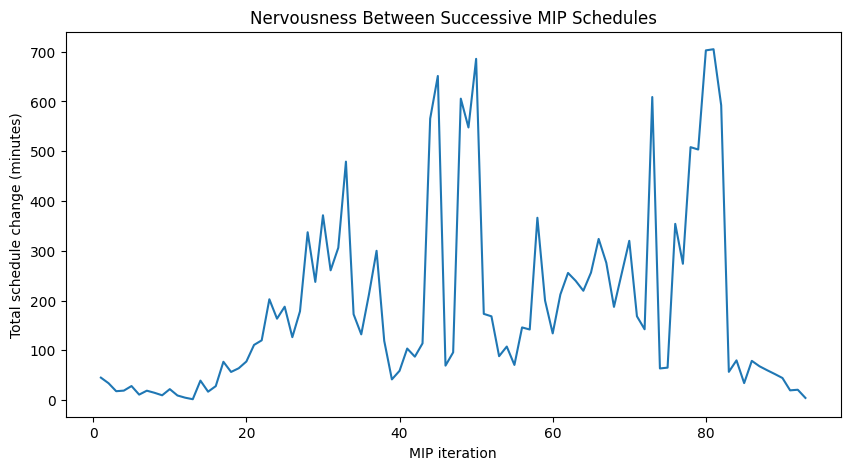

In [ ]:
# ============================================================
# NERVOUSNESS BETWEEN SUCCESSIVE MIP SCHEDULES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

if len(simulator._solutions) < 2:
    raise ValueError("Minstens 2 MIP solutions nodig")


rows = []

for k in range(1, len(simulator._solutions)):

    prev_sol = simulator._solutions[k - 1]
    curr_sol = simulator._solutions[k]

    total_change = 0
    max_change = 0
    n_changed = 0

    all_pairs = set(prev_sol.entry.keys()) | set(curr_sol.entry.keys())

    for key in all_pairs:

        prev_arr = prev_sol.entry.get(key)
        curr_arr = curr_sol.entry.get(key)

        if prev_arr is None or curr_arr is None:
            continue

        diff = abs(curr_arr - prev_arr)

        total_change += diff
        max_change = max(max_change, diff)

        if diff > 1:
            n_changed += 1

    rows.append({
        "iteration": k,
        "total_change_min": total_change / 60,
        "avg_change_min": (
            total_change / max(1, n_changed)
        ) / 60,
        "max_change_min": max_change / 60,
        "n_changed_segments": n_changed,
    })

df_nervousness = pd.DataFrame(rows)

print("==================================================")
print("SUCCESSIVE MIP NERVOUSNESS")
print("==================================================")

display(df_nervousness)


# ============================================================
# VISUALIZATION
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    df_nervousness["iteration"],
    df_nervousness["total_change_min"],
)

plt.xlabel("MIP iteration")
plt.ylabel("Total schedule change (minutes)")
plt.title("Nervousness Between Successive MIP Schedules")

plt.show()

In [ ]:
simulator._solutions

[Solution(status=optimal, objective=856.00, runtime=0.03s),
 Solution(status=optimal, objective=1957.60, runtime=0.06s),
 Solution(status=optimal, objective=1461.20, runtime=0.02s),
 Solution(status=optimal, objective=785.10, runtime=0.02s),
 Solution(status=optimal, objective=1246.00, runtime=0.01s),
 Solution(status=optimal, objective=1798.60, runtime=0.01s),
 Solution(status=optimal, objective=1107.10, runtime=0.01s),
 Solution(status=optimal, objective=634.00, runtime=0.04s),
 Solution(status=optimal, objective=1118.50, runtime=0.01s),
 Solution(status=optimal, objective=914.70, runtime=0.01s),
 Solution(status=optimal, objective=576.80, runtime=0.01s),
 Solution(status=optimal, objective=392.00, runtime=0.00s),
 Solution(status=optimal, objective=466.00, runtime=0.01s),
 Solution(status=optimal, objective=1063.90, runtime=0.02s),
 Solution(status=optimal, objective=4384.20, runtime=0.07s),
 Solution(status=optimal, objective=6123.70, runtime=0.09s),
 Solution(status=optimal, objec

In [ ]:
display(compare_train(2045, state, timetable, trains))

,segment,scheduled_entry,actual_entry,entry_delay,scheduled_exit,actual_exit,exit_delay
0,36:SCHAARBEEK-BRUSSEL-NOORD,86100.0,86220.0,120.0,86280.0,86417.0,137.0
1,BRUSSEL-NOORD -- platform 9 -- platform 9,86280.0,86417.0,137.0,86520.0,86520.0,0.0
2,0-4:BRUSSEL-NOORD-BRUSSEL-CONGRES,86520.0,86520.0,0.0,86640.0,86642.0,2.0
3,BRUSSEL-CONGRES -- platform 3 -- platform 3,86640.0,86642.0,2.0,86641.0,86643.0,2.0
4,0-4:BRUSSEL-CONGRES-BRUSSEL-CENTRAAL,86641.0,86643.0,2.0,86760.0,86743.0,-17.0
5,BRUSSEL-CENTRAAL -- platform 5 -- platform 6,86760.0,86743.0,-17.0,86820.0,86820.0,0.0
6,0-4:BRUSSEL-CENTRAAL-BRUSSEL-KAPELLEKERK,86820.0,86820.0,0.0,86940.0,86890.0,-50.0
7,BRUSSEL-KAPELLEKERK -- platform 1 -- platform 1,86940.0,86890.0,-50.0,86941.0,86891.0,-50.0
8,0-4:BRUSSEL-KAPELLEKERK-BRUSSEL-ZUID,86941.0,86891.0,-50.0,87060.0,87009.0,-51.0


In [ ]:
display(compare_train(11, state, timetable, trains))

,segment,scheduled_entry,actual_entry,entry_delay,scheduled_exit,actual_exit,exit_delay
0,0-1:BRUSSEL-ZUID-BRUSSEL-KAPELLEKERK,22860.0,22860.0,0.0,22980.0,22998.0,18.0
1,BRUSSEL-KAPELLEKERK -- platform 2 -- platform 1,22980.0,22998.0,18.0,22981.0,22999.0,18.0
2,0-1:BRUSSEL-KAPELLEKERK-BRUSSEL-CENTRAAL,22981.0,22999.0,18.0,23040.0,23061.0,21.0
3,BRUSSEL-CENTRAAL -- platform 3 -- platform 6,23040.0,23061.0,21.0,23041.0,23062.0,21.0
4,0-1:BRUSSEL-CENTRAAL-BRUSSEL-CONGRES,23041.0,23062.0,21.0,23100.0,23208.0,108.0
5,BRUSSEL-CONGRES -- platform 1 -- platform 4,23100.0,23208.0,108.0,23101.0,23209.0,108.0
6,0-1:BRUSSEL-CONGRES-BRUSSEL-NOORD,23101.0,23209.0,108.0,23220.0,23335.0,115.0
7,BRUSSEL-NOORD -- platform 4 -- platform 4,23220.0,23335.0,115.0,23340.0,23455.0,115.0
8,36N:BRUSSEL-NOORD-SCHAARBEEK,23340.0,23455.0,115.0,23520.0,23589.0,69.0


In [ ]:
display(compare_train(18, state, timetable, trains))

,segment,scheduled_entry,actual_entry,entry_delay,scheduled_exit,actual_exit,exit_delay
0,36N:SCHAARBEEK-BRUSSEL-NOORD,33660.0,33690.0,30.0,33840.0,34033.0,193.0
1,BRUSSEL-NOORD -- platform 3 -- platform 3,33840.0,34033.0,193.0,33960.0,34093.0,133.0
2,0-2:BRUSSEL-NOORD-BRUSSEL-CONGRES,33960.0,34093.0,133.0,34080.0,34211.0,131.0
3,BRUSSEL-CONGRES -- platform 4 -- platform 4,34080.0,34211.0,131.0,34081.0,34212.0,131.0
4,0-2:BRUSSEL-CONGRES-BRUSSEL-CENTRAAL,34081.0,34212.0,131.0,34140.0,34282.0,142.0
5,BRUSSEL-CENTRAAL -- platform 1 -- platform 1,34140.0,34282.0,142.0,34141.0,34283.0,142.0
6,0-2:BRUSSEL-CENTRAAL-BRUSSEL-KAPELLEKERK,34141.0,34283.0,142.0,34260.0,34343.0,83.0
7,BRUSSEL-KAPELLEKERK -- platform 4 -- platform 4,34260.0,34343.0,83.0,34261.0,34344.0,83.0
8,0-2:BRUSSEL-KAPELLEKERK-BRUSSEL-ZUID,34261.0,34344.0,83.0,34380.0,34589.0,209.0


END DELAY STATISTICS

Passenger:
count    1028.000000
mean       37.747276
std        80.365697
min       -91.000000
25%         0.000000
50%         0.000000
75%        59.250000
max       621.400000
Name: entry_delay, dtype: float64

Freight:
count     182.000000
mean       36.161538
std       181.609023
min      -276.200000
25%         0.000000
50%         0.000000
75%        21.800000
max      1441.700000
Name: entry_delay, dtype: float64


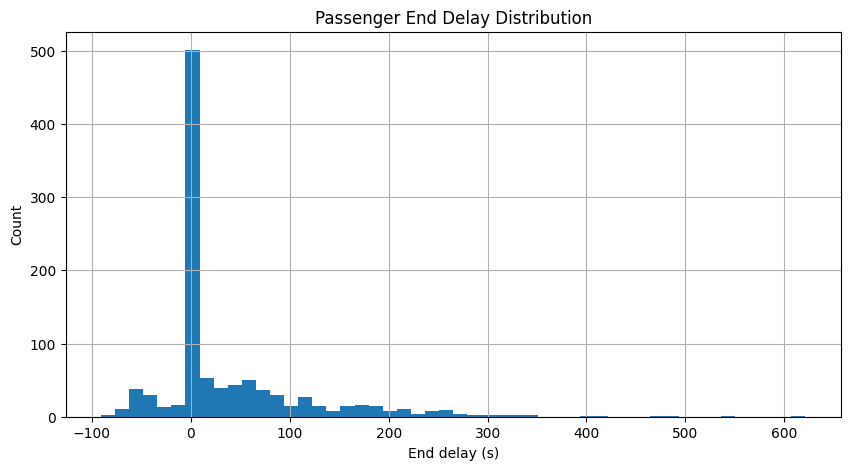

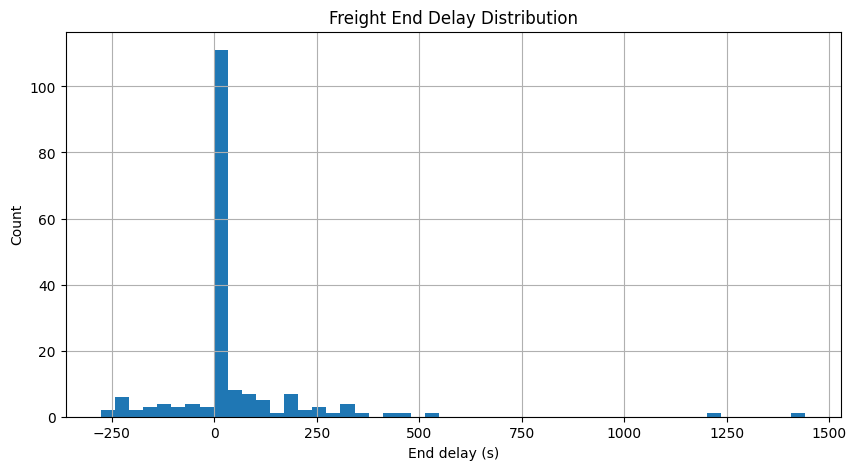


INTERMEDIATE DELAY STATISTICS

Passenger intermediate:
count    9044.000000
mean       37.841390
std        71.766493
min      -146.000000
25%         0.000000
50%        13.000000
75%        62.000000
max       598.000000
Name: entry_delay, dtype: float64

Freight intermediate:
count     472.000000
mean       14.246186
std       240.232631
min      -276.200000
25%       -52.000000
50%       -18.200000
75%         0.000000
max      1466.400000
Name: entry_delay, dtype: float64


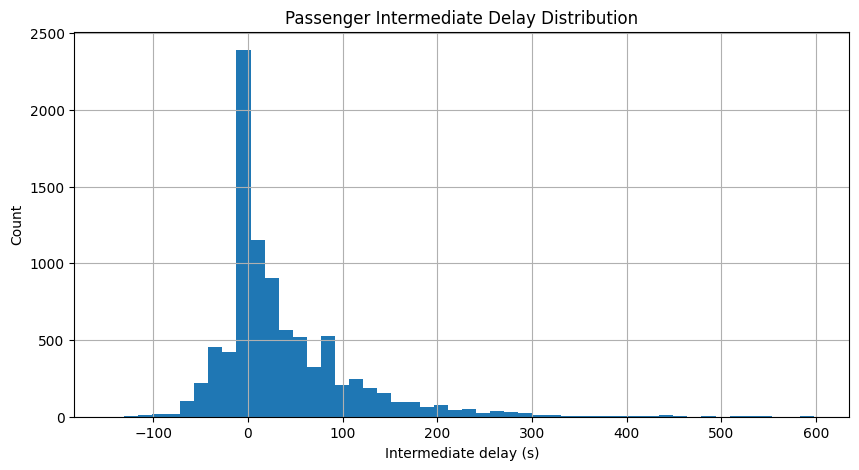

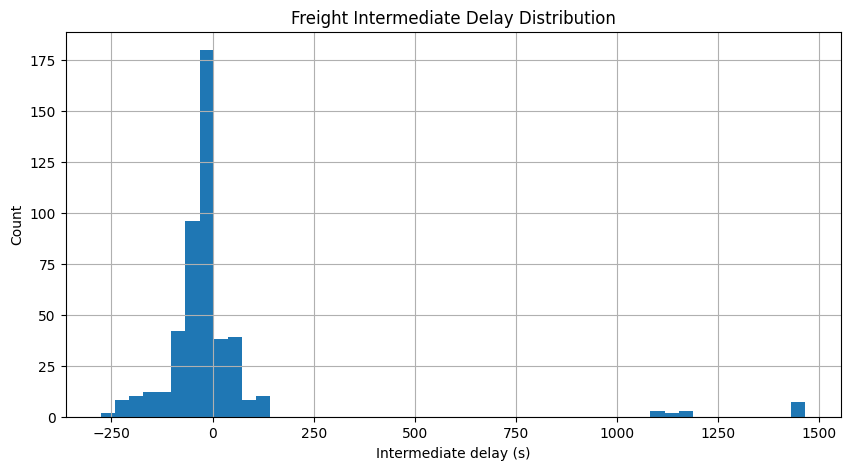


SIGN ANALYSIS

Passenger END
-------------
Negative :    115 ( 11.2%)
Zero     :    462 ( 44.9%)
Positive :    451 ( 43.9%)

Freight END
-----------
Negative :     27 ( 14.8%)
Zero     :    103 ( 56.6%)
Positive :     52 ( 28.6%)

Passenger INTERMEDIATE
----------------------
Negative :   1939 ( 21.4%)
Zero     :   1543 ( 17.1%)
Positive :   5562 ( 61.5%)

Freight INTERMEDIATE
--------------------
Negative :    285 ( 60.4%)
Zero     :     76 ( 16.1%)
Positive :    111 ( 23.5%)


In [ ]:
# ------------------------------------------------------------
# DELAY DISTRIBUTION ANALYSIS
# ------------------------------------------------------------

import matplotlib.pyplot as plt
import pandas as pd


# ============================================================
# 1. END DELAY DISTRIBUTIONS
# ============================================================

# Laatste segment per trein
last_seg = (
    df.sort_values("planned_entry")
      .groupby(["train_id", "train_type"])
      .last()
      .reset_index()
)

pass_end = last_seg[last_seg["train_type"] == "P"]["entry_delay"]
freight_end = last_seg[last_seg["train_type"] == "F"]["entry_delay"]

print("==================================================")
print("END DELAY STATISTICS")
print("==================================================")

print("\nPassenger:")
print(pass_end.describe())

print("\nFreight:")
print(freight_end.describe())


# Histogram passenger
plt.figure(figsize=(10, 5))
plt.hist(pass_end, bins=50)
plt.title("Passenger End Delay Distribution")
plt.xlabel("End delay (s)")
plt.ylabel("Count")
plt.grid(True)
plt.show()


# Histogram freight
plt.figure(figsize=(10, 5))
plt.hist(freight_end, bins=50)
plt.title("Freight End Delay Distribution")
plt.xlabel("End delay (s)")
plt.ylabel("Count")
plt.grid(True)
plt.show()


# ============================================================
# 2. INTERMEDIATE DELAY DISTRIBUTIONS
# ============================================================

# Intermediate = alle segmenten behalve laatste segment
last_pairs = set(
    zip(last_seg["train_id"], last_seg["segment_id"])
)

intermediate_df = df[
    ~df.apply(
        lambda r: (r["train_id"], r["segment_id"]) in last_pairs,
        axis=1
    )
]

pass_inter = intermediate_df[
    intermediate_df["train_type"] == "P"
]["entry_delay"]

freight_inter = intermediate_df[
    intermediate_df["train_type"] == "F"
]["entry_delay"]

print("\n==================================================")
print("INTERMEDIATE DELAY STATISTICS")
print("==================================================")

print("\nPassenger intermediate:")
print(pass_inter.describe())

print("\nFreight intermediate:")
print(freight_inter.describe())


# Histogram passenger intermediate
plt.figure(figsize=(10, 5))
plt.hist(pass_inter, bins=50)
plt.title("Passenger Intermediate Delay Distribution")
plt.xlabel("Intermediate delay (s)")
plt.ylabel("Count")
plt.grid(True)
plt.show()


# Histogram freight intermediate
plt.figure(figsize=(10, 5))
plt.hist(freight_inter, bins=50)
plt.title("Freight Intermediate Delay Distribution")
plt.xlabel("Intermediate delay (s)")
plt.ylabel("Count")
plt.grid(True)
plt.show()


# ============================================================
# 3. NEGATIVE VS POSITIVE DELAYS
# ============================================================

def summarize_signs(series, label):

    neg = (series < 0).sum()
    zero = (series == 0).sum()
    pos = (series > 0).sum()

    total = len(series)

    print(f"\n{label}")
    print("-" * len(label))

    print(f"Negative : {neg:6d} ({100*neg/total:5.1f}%)")
    print(f"Zero     : {zero:6d} ({100*zero/total:5.1f}%)")
    print(f"Positive : {pos:6d} ({100*pos/total:5.1f}%)")


print("\n==================================================")
print("SIGN ANALYSIS")
print("==================================================")

summarize_signs(pass_end, "Passenger END")
summarize_signs(freight_end, "Freight END")

summarize_signs(pass_inter, "Passenger INTERMEDIATE")
summarize_signs(freight_inter, "Freight INTERMEDIATE")

In [ ]:
# ------------------------------------------------------------
# TOP DELAYED TRAINS
# ------------------------------------------------------------

top_pass = (
    last_seg[last_seg["train_type"] == "P"]
    .sort_values("entry_delay", ascending=False)
    .head(10)
)

top_freight = (
    last_seg[last_seg["train_type"] == "F"]
    .sort_values("entry_delay", ascending=False)
    .head(10)
)

print("TOP PASSENGER")
display(
    top_pass[
        ["train_id", "segment_id", "entry_delay"]
    ]
)

print("\nTOP FREIGHT")
display(
    top_freight[
        ["train_id", "segment_id", "entry_delay"]
    ]
)

TOP PASSENGER


,train_id,segment_id,entry_delay
316,2088,0-2:BRUSSEL-KAPELLEKERK-BRUSSEL-ZUID,621.4
741,3689,0-6:BRUSSEL-KAPELLEKERK-BRUSSEL-ZUID,542.0
212,1955,25:BRUSSEL-NOORD-SCHAARBEEK,492.4
76,539,0-2:BRUSSEL-KAPELLEKERK-BRUSSEL-ZUID,473.0
113,1538,50C:BRUSSEL-ZUID-ANDERLECHT,419.0
44,442,0-2:BRUSSEL-KAPELLEKERK-BRUSSEL-ZUID,406.6
613,3214,60:JETTE-ZELLIK,345.0
150,1757,25:BRUSSEL-NOORD-SCHAARBEEK,339.0
766,3727,0-2:BRUSSEL-KAPELLEKERK-BRUSSEL-ZUID,336.0
279,2039,124:BRUSSEL-ZUID-VORST-OOST,326.0



TOP FREIGHT


,train_id,segment_id,entry_delay
1207,900179,36N:SCHAARBEEK-BRUSSEL-NOORD,1441.7
1183,900155,36N:SCHAARBEEK-BRUSSEL-NOORD,1201.4
1107,900079,36N:SCHAARBEEK-BRUSSEL-NOORD,532.8
1161,900133,36N:SCHAARBEEK-BRUSSEL-NOORD,460.6
1196,900168,36N:SCHAARBEEK-BRUSSEL-NOORD,425.1
1200,900172,36N:SCHAARBEEK-BRUSSEL-NOORD,370.1
1169,900141,36N:SCHAARBEEK-BRUSSEL-NOORD,341.6
1145,900117,36N:SCHAARBEEK-BRUSSEL-NOORD,340.6
1174,900146,36N:SCHAARBEEK-BRUSSEL-NOORD,332.8
1097,900069,36N:SCHAARBEEK-BRUSSEL-NOORD,315.1


In [ ]:
# ------------------------------------------------------------
# MEAN DELAY PER SEGMENT
# ------------------------------------------------------------

segment_delay = (
    df.groupby(["segment_id", "train_type"])["entry_delay"]
      .mean()
      .reset_index()
)

print("PASSENGER")
display(
    segment_delay[
        segment_delay["train_type"] == "P"
    ]
    .sort_values("entry_delay", ascending=False)
    .head(20)
)

print("\nFREIGHT")
display(
    segment_delay[
        segment_delay["train_type"] == "F"
    ]
    .sort_values("entry_delay", ascending=False)
    .head(20)
)

PASSENGER


,segment_id,train_type,entry_delay
174,BRUSSEL-ZUID -- IC 05: CHARLEROI-CENTRAL -> AN...,P,195.333333
175,BRUSSEL-ZUID -- IC 07: CHARLEROI-CENTRAL -> ES...,P,187.294118
183,BRUSSEL-ZUID -- IC 23-1: GENT-SINT-PIETERS -> ...,P,149.687500
125,BRUSSEL-CONGRES -- platform 1 -- platform 3,P,131.400000
172,BRUSSEL-ZUID -- IC 03: GENK -> BLANKENBERGE --...,P,130.670000
187,BRUSSEL-ZUID -- IC 29: GENT-SINT-PIETERS -> GE...,P,106.250000
126,BRUSSEL-CONGRES -- platform 1 -- platform 4,P,100.000000
49,28(1):THURN EN TAXIS-JETTE,P,96.266667
80,60:JETTE-ZELLIK,P,89.607843
4,0-2:BRUSSEL-CENTRAAL-BRUSSEL-KAPELLEKERK,P,86.644670



FREIGHT


,segment_id,train_type,entry_delay
59,36N:SCHAARBEEK-BRUSSEL-NOORD,F,117.103614
199,SCHAARBEEK -- T2b,F,70.315152
204,THURN EN TAXIS -- platform 1,F,64.609091
53,28:THURN EN TAXIS-SCHAARBEEK,F,64.609091
200,SIMONIS -- platform 1,F,53.224242
47,28(1):SIMONIS-THURN EN TAXIS,F,53.224242
41,28(1):BRUSSEL-WEST-SIMONIS,F,47.551515
165,BRUSSEL-WEST -- platform 1,F,47.551515
83,BOCKSTAEL -- platform 1,F,40.300000
61,50:BOCKSTAEL-BRUSSEL-NOORD,F,40.300000


In [ ]:
# ------------------------------------------------------------
# DELAY RATIO WITHOUT SCHAARBEEK -> BRUSSEL-NOORD
# ------------------------------------------------------------

import pandas as pd


# ============================================================
# 1. REMOVE TARGET SEGMENT
# ============================================================

excluded_segment = "36N:SCHAARBEEK-BRUSSEL-NOORD"

df_filtered = df[
    df["segment_id"] != excluded_segment
].copy()


# ============================================================
# 2. RECOMPUTE END DELAYS
# ============================================================

# Nieuwe "laatste segmenten" nadat het segment verwijderd is
last_seg_filtered = (
    df_filtered
    .sort_values("planned_entry")
    .groupby(["train_id", "train_type"])
    .last()
    .reset_index()
)

pass_mask = last_seg_filtered["train_type"] == "P"
freight_mask = last_seg_filtered["train_type"] == "F"

ted_p = (
    last_seg_filtered[pass_mask]["entry_delay"]
    .clip(lower=0)
    .sum()
)

ted_f = (
    last_seg_filtered[freight_mask]["entry_delay"]
    .clip(lower=0)
    .sum()
)

n_pass = pass_mask.sum()
n_freight = freight_mask.sum()

avg_p = ted_p / n_pass
avg_f = ted_f / n_freight

delay_ratio_filtered = avg_f / avg_p


# ============================================================
# 3. ORIGINAL METRICS
# ============================================================

orig = compute_metrics(df)

print("==================================================")
print("ORIGINAL")
print("==================================================")

print(f"TED_passenger : {orig['TED_passenger']:.1f}")
print(f"TED_freight   : {orig['TED_freight']:.1f}")
print(f"delay_ratio   : {orig['delay_ratio']:.3f}")

print("\n==================================================")
print("WITHOUT SCHAARBEEK -> BRUSSEL-NOORD")
print("==================================================")

print(f"TED_passenger : {ted_p:.1f}")
print(f"TED_freight   : {ted_f:.1f}")
print(f"delay_ratio   : {delay_ratio_filtered:.3f}")


# ============================================================
# 4. IMPACT ANALYSIS
# ============================================================

print("\n==================================================")
print("IMPACT")
print("==================================================")

delta = delay_ratio_filtered - orig["delay_ratio"]

print(f"Absolute change : {delta:+.3f}")
print(f"Relative change : {100 * delta / orig['delay_ratio']:+.1f}%")

ORIGINAL
TED_passenger : 43613.1
TED_freight   : 10308.4
delay_ratio   : 1.335

WITHOUT SCHAARBEEK -> BRUSSEL-NOORD
TED_passenger : 43613.1
TED_freight   : 3478.6
delay_ratio   : 0.621

IMPACT
Absolute change : -0.714
Relative change : -53.5%


BASELINE
delay_ratio = 1.335



TOP IMPACT SEGMENTS


,segment_id,new_delay_ratio,delta_ratio,abs_impact
0,36N:SCHAARBEEK-BRUSSEL-NOORD,0.621165,-0.713881,0.713881
1,25:BRUSSEL-NOORD-SCHAARBEEK,1.647620,0.312574,0.312574
2,36N:BRUSSEL-NOORD-SCHAARBEEK,1.249444,-0.085601,0.085601
3,124:BRUSSEL-ZUID-VORST-OOST,1.272351,-0.062694,0.062694
4,50C:ANDERLECHT-BRUSSEL-ZUID,1.390993,0.055948,0.055948
5,28(1):BRUSSEL-WEST-BRUSSEL-ZUID,1.285367,-0.049678,0.049678
6,50C:BRUSSEL-ZUID-ANDERLECHT,1.286398,-0.048647,0.048647
7,27:BRUSSEL-NOORD-SCHAARBEEK,1.287915,-0.047131,0.047131
8,50:BRUSSEL-NOORD-SCHAARBEEK,1.289112,-0.045933,0.045933
9,36:BRUSSEL-NOORD-SCHAARBEEK,1.294961,-0.040084,0.040084


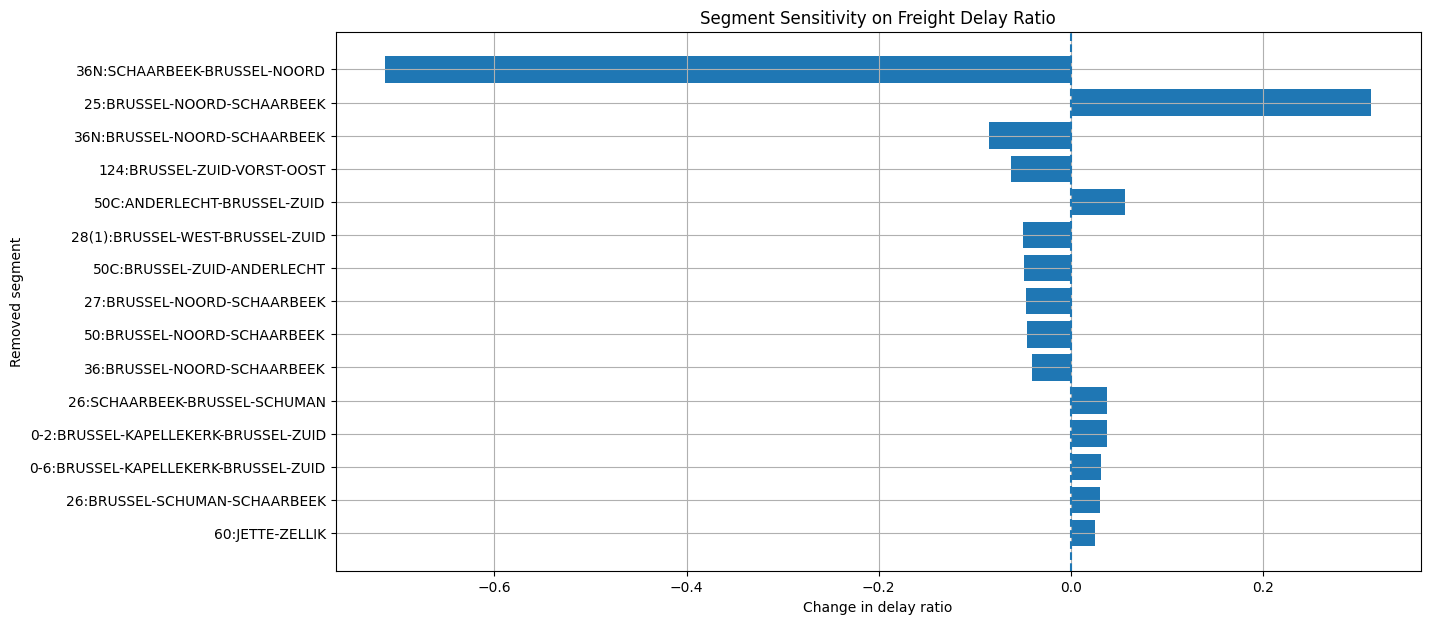

In [ ]:
# ------------------------------------------------------------
# SEGMENT SENSITIVITY ANALYSIS
# ------------------------------------------------------------

import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# BASELINE
# ============================================================

baseline = compute_metrics(df)

baseline_ratio = baseline["delay_ratio"]

print("==================================================")
print("BASELINE")
print("==================================================")

print(f"delay_ratio = {baseline_ratio:.3f}")


# ============================================================
# FUNCTION
# ============================================================

def recompute_delay_ratio_without_segment(df, excluded_segment):

    # verwijder segment
    df_filtered = df[df["segment_id"] != excluded_segment].copy()

    # bepaal nieuw laatste segment per trein
    last_seg = (
        df_filtered
        .sort_values("planned_entry")
        .groupby(["train_id", "train_type"])
        .last()
        .reset_index()
    )

    pass_mask = last_seg["train_type"] == "P"
    freight_mask = last_seg["train_type"] == "F"

    ted_p = (
        last_seg[pass_mask]["entry_delay"]
        .clip(lower=0)
        .sum()
    )

    ted_f = (
        last_seg[freight_mask]["entry_delay"]
        .clip(lower=0)
        .sum()
    )

    n_pass = pass_mask.sum()
    n_freight = freight_mask.sum()

    if n_pass == 0 or n_freight == 0:
        return None

    avg_p = ted_p / n_pass

    if avg_p <= 0:
        return None

    avg_f = ted_f / n_freight

    return avg_f / avg_p


# ============================================================
# ANALYZE ALL SEGMENTS
# ============================================================

results = []

segments = sorted(df["segment_id"].unique())

for seg in segments:

    try:
        new_ratio = recompute_delay_ratio_without_segment(df, seg)

        if new_ratio is None:
            continue

        delta = new_ratio - baseline_ratio

        results.append({
            "segment_id": seg,
            "new_delay_ratio": new_ratio,
            "delta_ratio": delta,
            "abs_impact": abs(delta),
        })

    except Exception as e:

        print(f"FAILED for {seg}: {e}")


# ============================================================
# RESULTS TABLE
# ============================================================

sensitivity_df = (
    pd.DataFrame(results)
    .sort_values("abs_impact", ascending=False)
    .reset_index(drop=True)
)

print("\n==================================================")
print("TOP IMPACT SEGMENTS")
print("==================================================")

display(sensitivity_df.head(20))


# ============================================================
# PLOT
# ============================================================

top_plot = sensitivity_df.head(15)

plt.figure(figsize=(14, 7))

plt.barh(
    top_plot["segment_id"][::-1],
    top_plot["delta_ratio"][::-1],
)

plt.axvline(0, linestyle="--")

plt.xlabel("Change in delay ratio")
plt.ylabel("Removed segment")
plt.title("Segment Sensitivity on Freight Delay Ratio")

plt.grid(True)

plt.show()

BASELINE
TED_combined = 53921.5

TOP IMPACT SEGMENTS ON TOTAL END DELAY


,segment_id,new_TED_combined,delta_TED,abs_impact
0,36N:SCHAARBEEK-BRUSSEL-NOORD,47091.7,-6829.8,6829.8
1,50C:BRUSSEL-ZUID-ANDERLECHT,57925.5,4004.0,4004.0
2,25:BRUSSEL-NOORD-SCHAARBEEK,56915.1,2993.6,2993.6
3,36N:BRUSSEL-NOORD-SCHAARBEEK,56909.5,2988.0,2988.0
4,124:BRUSSEL-ZUID-VORST-OOST,56070.5,2149.0,2149.0
5,27:BRUSSEL-NOORD-SCHAARBEEK,55517.5,1596.0,1596.0
6,50:BRUSSEL-NOORD-SCHAARBEEK,55475.5,1554.0,1554.0
7,36:BRUSSEL-NOORD-SCHAARBEEK,55271.5,1350.0,1350.0
8,0-2:BRUSSEL-KAPELLEKERK-BRUSSEL-ZUID,52732.7,-1188.8,1188.8
9,0-6:BRUSSEL-KAPELLEKERK-BRUSSEL-ZUID,52909.5,-1012.0,1012.0


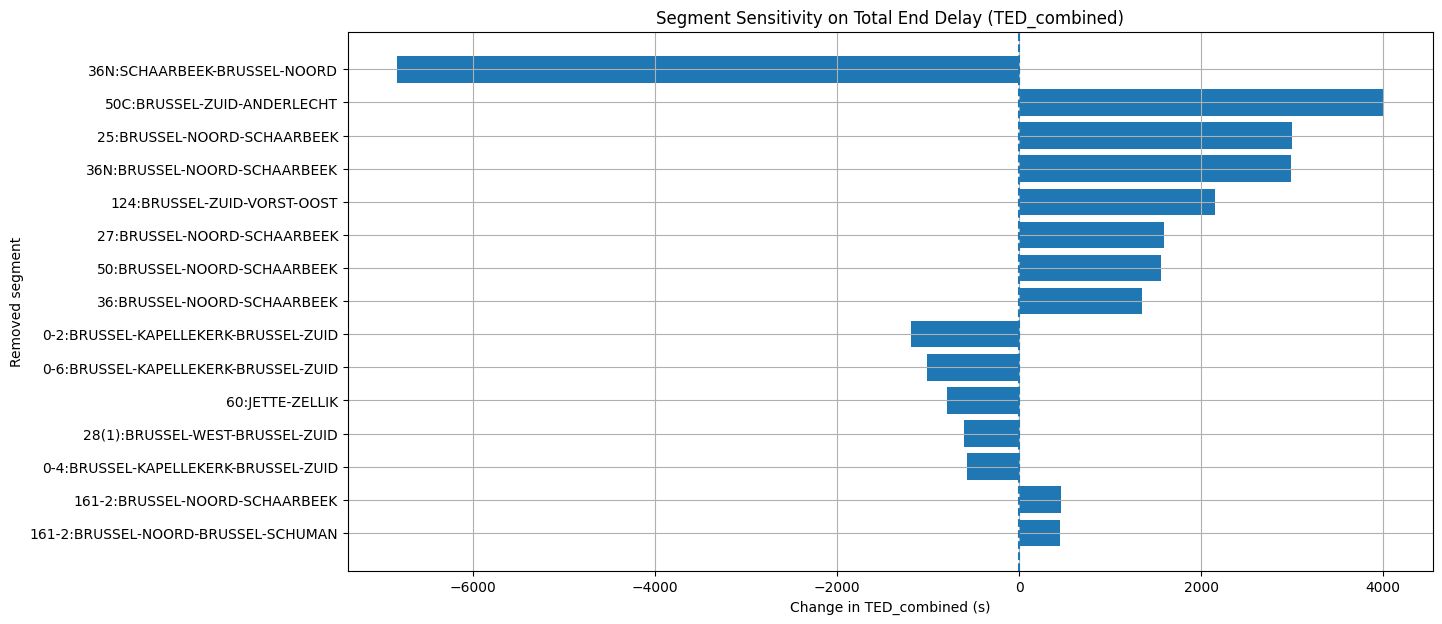

In [ ]:
# ------------------------------------------------------------
# SEGMENT SENSITIVITY ANALYSIS ON TOTAL END DELAY
# ------------------------------------------------------------

import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# BASELINE
# ============================================================

baseline = compute_metrics(df)

baseline_ted = baseline["TED_combined"]

print("==================================================")
print("BASELINE")
print("==================================================")

print(f"TED_combined = {baseline_ted:.1f}")


# ============================================================
# FUNCTION
# ============================================================

def recompute_ted_without_segment(df, excluded_segment):

    # verwijder segment
    df_filtered = df[df["segment_id"] != excluded_segment].copy()

    # nieuw laatste segment per trein
    last_seg = (
        df_filtered
        .sort_values("planned_entry")
        .groupby(["train_id", "train_type"])
        .last()
        .reset_index()
    )

    ted_p = (
        last_seg[last_seg["train_type"] == "P"]["entry_delay"]
        .clip(lower=0)
        .sum()
    )

    ted_f = (
        last_seg[last_seg["train_type"] == "F"]["entry_delay"]
        .clip(lower=0)
        .sum()
    )

    return ted_p + ted_f


# ============================================================
# ANALYZE ALL SEGMENTS
# ============================================================

results = []

segments = sorted(df["segment_id"].unique())

for seg in segments:

    try:

        new_ted = recompute_ted_without_segment(df, seg)

        delta = new_ted - baseline_ted

        results.append({
            "segment_id": seg,
            "new_TED_combined": new_ted,
            "delta_TED": delta,
            "abs_impact": abs(delta),
        })

    except Exception as e:

        print(f"FAILED for {seg}: {e}")


# ============================================================
# RESULTS TABLE
# ============================================================

sensitivity_ted_df = (
    pd.DataFrame(results)
    .sort_values("abs_impact", ascending=False)
    .reset_index(drop=True)
)

print("\n==================================================")
print("TOP IMPACT SEGMENTS ON TOTAL END DELAY")
print("==================================================")

display(sensitivity_ted_df.head(20))


# ============================================================
# PLOT
# ============================================================

top_plot = sensitivity_ted_df.head(15)

plt.figure(figsize=(14, 7))

plt.barh(
    top_plot["segment_id"][::-1],
    top_plot["delta_TED"][::-1],
)

plt.axvline(0, linestyle="--")

plt.xlabel("Change in TED_combined (s)")
plt.ylabel("Removed segment")

plt.title(
    "Segment Sensitivity on Total End Delay (TED_combined)"
)

plt.grid(True)

plt.show()

TOP SEGMENTS BY MEAN DELAY


,Freight,Passenger,Combined
segment_id,,,
BRUSSEL-ZUID -- IC 05: CHARLEROI-CENTRAL -> ANTWERPEN-CENTRAAL -- IC 05: CHARLEROI-CENTRAL -> ANTWERPEN-CENTRAAL,0.000000,195.333333,195.333333
BRUSSEL-ZUID -- IC 07: CHARLEROI-CENTRAL -> ESSEN -- IC 07: CHARLEROI-CENTRAL -> ESSEN,0.000000,187.294118,187.294118
36N:SCHAARBEEK-BRUSSEL-NOORD,117.103614,54.097203,171.200817
BRUSSEL-ZUID -- IC 23-1: GENT-SINT-PIETERS -> BRUSSELS AIRPORT - ZAVENTEM -- IC 23-1: GENT-SINT-PIETERS -> BRUSSELS AIRPORT - ZAVENTEM,0.000000,149.687500,149.687500
BRUSSEL-CONGRES -- platform 1 -- platform 3,0.000000,131.400000,131.400000
BRUSSEL-ZUID -- IC 03: GENK -> BLANKENBERGE -- IC 03: GENK -> BLANKENBERGE,0.000000,130.670000,130.670000
28(1):SIMONIS-THURN EN TAXIS,53.224242,65.933333,119.157576
BRUSSEL-ZUID -- IC 29: GENT-SINT-PIETERS -> GENK -- IC 29: GENT-SINT-PIETERS -> GENK,0.000000,106.250000,106.250000
BRUSSEL-CONGRES -- platform 1 -- platform 4,0.000000,100.000000,100.000000


/var/folders/53/wjg1bq612jgb33nbx7ppjxpc0000gn/T/ipykernel_79785/4020423675.py:92: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


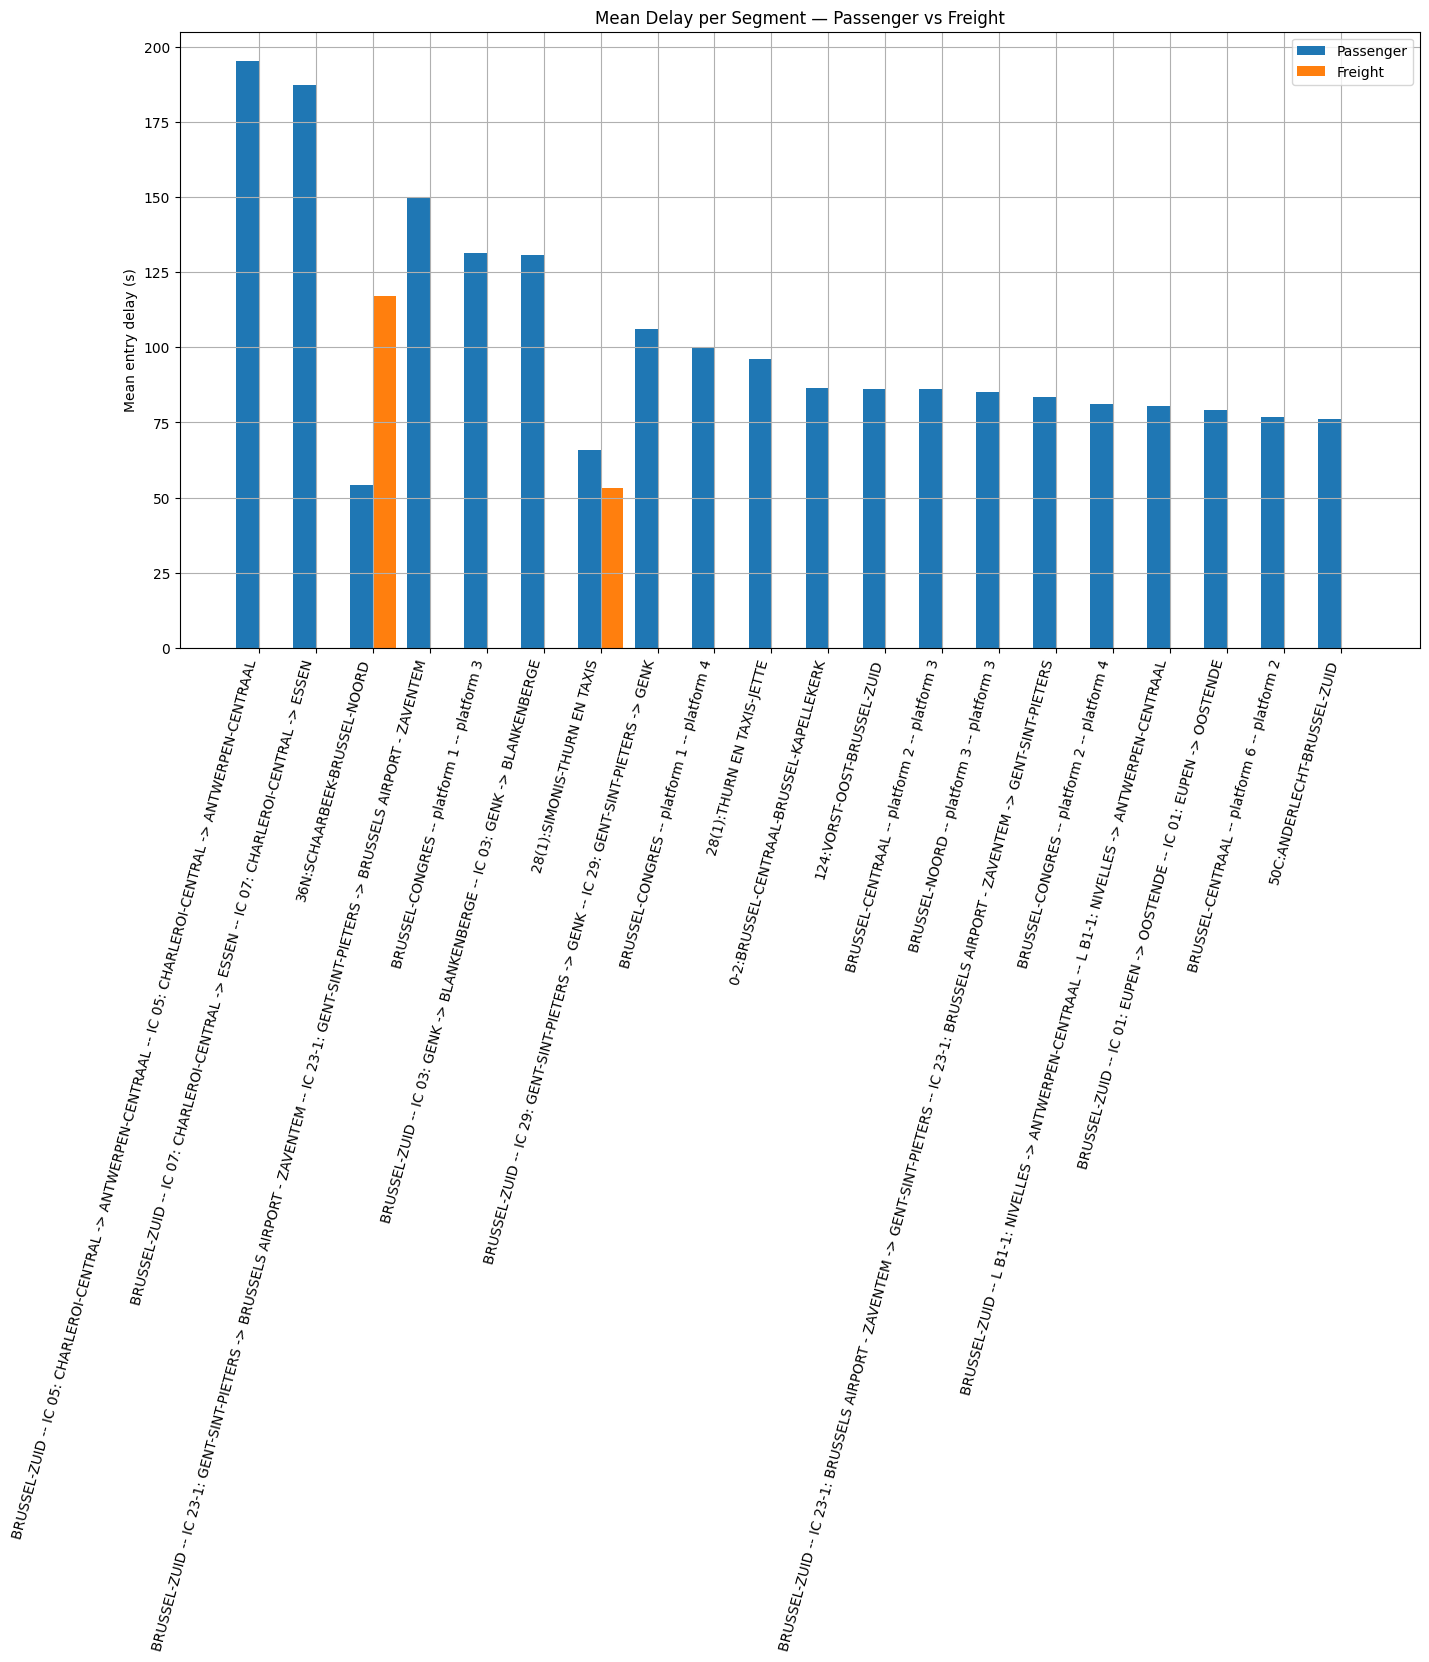

In [ ]:
# ------------------------------------------------------------
# MEAN DELAY PER SEGMENT (PASSENGER VS FREIGHT)
# ------------------------------------------------------------

import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# MEAN DELAY PER SEGMENT & TRAIN TYPE
# ============================================================

segment_delay = (
    df.groupby(["segment_id", "train_type"])["entry_delay"]
      .mean()
      .reset_index()
)

# pivot zodat passenger/freight aparte kolommen worden
pivot = (
    segment_delay
    .pivot(
        index="segment_id",
        columns="train_type",
        values="entry_delay"
    )
    .fillna(0)
)

pivot.columns.name = None

# hernoem kolommen indien aanwezig
pivot = pivot.rename(columns={
    "P": "Passenger",
    "F": "Freight",
})

# totale gemiddelde delay
pivot["Combined"] = pivot.sum(axis=1)

# sorteer op totale impact
pivot = (
    pivot.sort_values("Combined", ascending=False)
         .head(20)
)

print("==================================================")
print("TOP SEGMENTS BY MEAN DELAY")
print("==================================================")

display(pivot)


# ============================================================
# PLOT
# ============================================================

fig, ax = plt.subplots(figsize=(16, 8))

x = range(len(pivot))

width = 0.4

ax.bar(
    [i - width/2 for i in x],
    pivot["Passenger"],
    width=width,
    label="Passenger",
)

ax.bar(
    [i + width/2 for i in x],
    pivot["Freight"],
    width=width,
    label="Freight",
)

ax.set_xticks(list(x))
ax.set_xticklabels(
    pivot.index,
    rotation=75,
    ha="right"
)

ax.set_ylabel("Mean entry delay (s)")
ax.set_title("Mean Delay per Segment — Passenger vs Freight")

ax.legend()

ax.grid(True)

plt.tight_layout()
plt.show()

TOP FINAL SEGMENTS BY MEAN END DELAY


,Freight,Passenger,Combined
segment_id,,,
36N:SCHAARBEEK-BRUSSEL-NOORD,117.103614,0.000000,117.103614
0-2:BRUSSEL-KAPELLEKERK-BRUSSEL-ZUID,0.000000,65.842262,65.842262
0-4:BRUSSEL-KAPELLEKERK-BRUSSEL-ZUID,0.000000,59.047107,59.047107
50:JETTE-SINT-AGATHA-BERCHEM,0.000000,46.937500,46.937500
27:BRUSSEL-NOORD-BRUSSEL-SCHUMAN,0.000000,41.250000,41.250000
50:BOCKSTAEL-BRUSSEL-NOORD,40.300000,0.000000,40.300000
50C:BRUSSEL-ZUID-ANDERLECHT,0.000000,28.561446,28.561446
0-6:BRUSSEL-KAPELLEKERK-BRUSSEL-ZUID,0.000000,28.300000,28.300000
50:BOCKSTAEL-BRUSSEL-SCHUMAN,0.000000,25.714286,25.714286


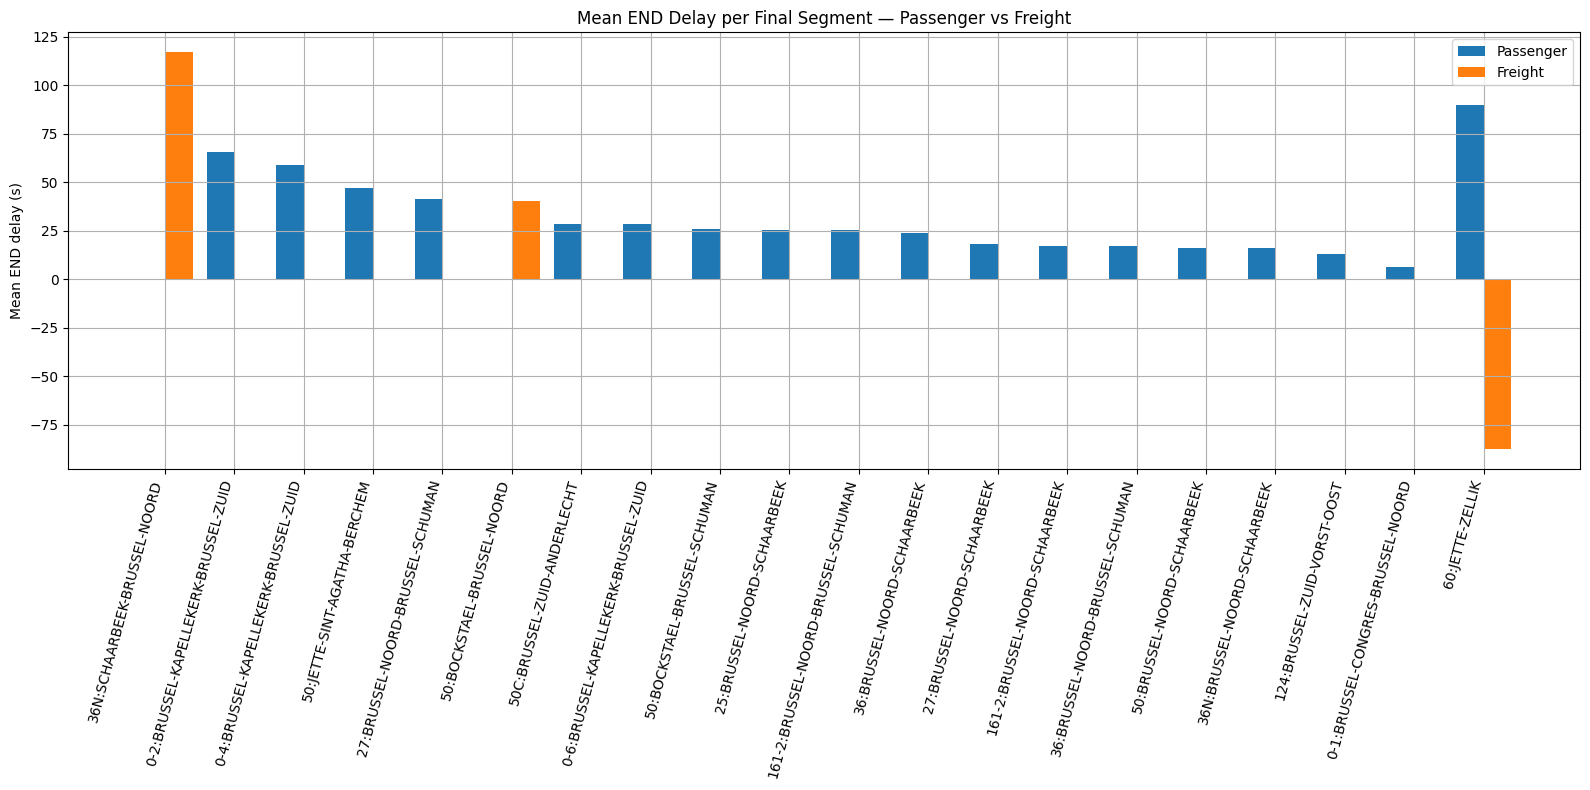

In [ ]:
# ------------------------------------------------------------
# END DELAY PER SEGMENT (PASSENGER VS FREIGHT)
# ------------------------------------------------------------

import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# LAST SEGMENT PER TRAIN
# ============================================================

last_seg = (
    df.sort_values("planned_entry")
      .groupby(["train_id", "train_type"])
      .last()
      .reset_index()
)


# ============================================================
# MEAN END DELAY PER FINAL SEGMENT
# ============================================================

end_delay = (
    last_seg
    .groupby(["segment_id", "train_type"])["entry_delay"]
    .mean()
    .reset_index()
)

pivot = (
    end_delay
    .pivot(
        index="segment_id",
        columns="train_type",
        values="entry_delay"
    )
    .fillna(0)
)

pivot.columns.name = None

pivot = pivot.rename(columns={
    "P": "Passenger",
    "F": "Freight",
})

pivot["Combined"] = pivot.sum(axis=1)

pivot = (
    pivot
    .sort_values("Combined", ascending=False)
    .head(20)
)

print("==================================================")
print("TOP FINAL SEGMENTS BY MEAN END DELAY")
print("==================================================")

display(pivot)


# ============================================================
# PLOT
# ============================================================

fig, ax = plt.subplots(figsize=(16, 8))

x = range(len(pivot))

width = 0.4

ax.bar(
    [i - width/2 for i in x],
    pivot["Passenger"],
    width=width,
    label="Passenger",
)

ax.bar(
    [i + width/2 for i in x],
    pivot["Freight"],
    width=width,
    label="Freight",
)

ax.set_xticks(list(x))

ax.set_xticklabels(
    pivot.index,
    rotation=75,
    ha="right"
)

ax.set_ylabel("Mean END delay (s)")
ax.set_title("Mean END Delay per Final Segment — Passenger vs Freight")

ax.legend()

ax.grid(True)

plt.tight_layout()
plt.show()

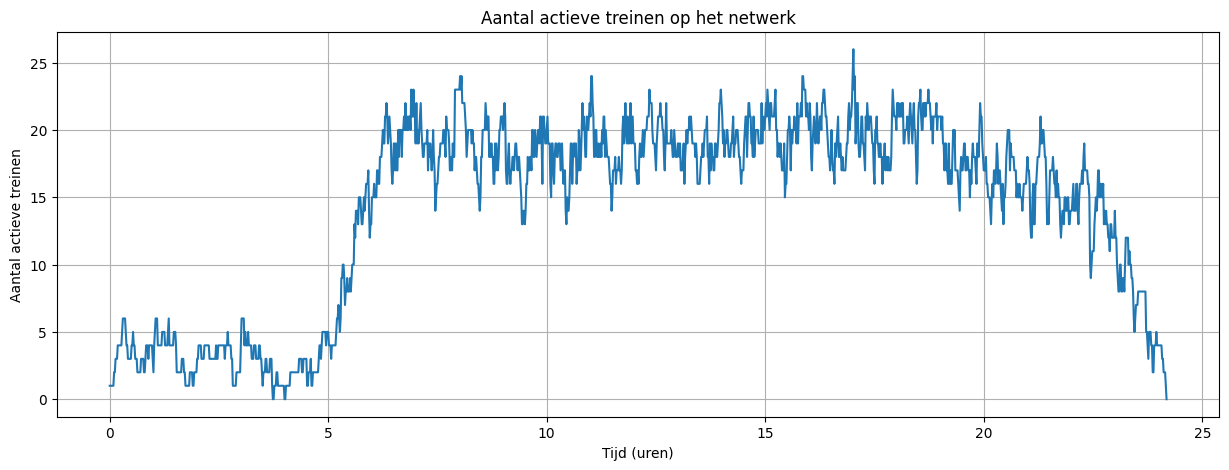

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# Intervallen bepalen
# ============================================================

intervals = []

simulation_end = state.current_time

for train_id, seg_data in state._actual.items():

    entries = []
    exits   = []

    for seg_id, times in seg_data.items():

        entry, exit_ = times

        if entry is not None:
            entries.append(entry)

        if exit_ is not None:
            exits.append(exit_)

    if not entries:
        continue

    start = min(entries)

    if exits:
        end = max(exits)
    else:
        end = simulation_end

    intervals.append((start, end))

# ============================================================
# Tijdas (elke minuut)
# ============================================================

max_time = max(end for _, end in intervals)

times = np.arange(
    0,
    max_time + 60,
    60,  # 1 minuut resolutie
)

# ============================================================
# Actieve treinen tellen
# ============================================================

active_counts = []

for t in times:

    active = sum(
        start <= t <= end
        for start, end in intervals
    )

    active_counts.append(active)

# ============================================================
# Plot
# ============================================================

plt.figure(figsize=(15, 5))

plt.plot(
    times / 3600,
    active_counts,
)

plt.xlabel("Tijd (uren)")
plt.ylabel("Aantal actieve treinen")
plt.title("Aantal actieve treinen op het netwerk")

plt.grid(True)

plt.show()

In [ ]:
print("Aantal treinen totaal:", len(state._trains))
print("Aantal treinen ooit gestart:", len(state._actual))
print("Aantal actieve treinen nu:", len(state.active_train_ids()))
max_active = max(active_counts)

print("Maximum simultaan actieve treinen:", max_active)

Aantal treinen totaal: 1210
Aantal treinen ooit gestart: 1210
Aantal actieve treinen nu: 0
Maximum simultaan actieve treinen: 26


In [ ]:

# ============================================================
# COMPARE GOLD TIMETABLE VS SAMPLING DISTRIBUTIONS
# ============================================================

import pandas as pd
import numpy as np

from data.timetable import load_gold
from data.running_distributions import _load

# ============================================================
# LOAD DATA
# ============================================================

N_FREIGHT = 182

gold = load_gold("combined", N_FREIGHT)
dist = _load()

# ============================================================
# KEEP ONLY BETWEEN-STATION SEGMENTS
# ============================================================

between = gold[gold["SOURCE"] != gold["TARGET"]].copy()

# running time uit gold timetable
between["running_time"] = (
    between["EXIT_SECONDS"] -
    between["ENTRY_SECONDS"]
)

between = between[between["running_time"] > 0]

# ============================================================
# TIMETABLE STATISTICS
# ============================================================

tt_stats = (
    between.groupby("SECTION")["running_time"]
    .agg(
        timetable_mean="mean",
        timetable_median="median",
        timetable_std="std",
        timetable_min="min",
        timetable_max="max",
        timetable_n="count",
    )
    .reset_index()
)

# ============================================================
# SAMPLE DISTRIBUTION STATISTICS
# ============================================================

rows = []

for section, section_data in dist.items():

    all_samples = []

    for train_type, dyn_data in section_data.items():

        for dynamics, period_data in dyn_data.items():

            for period, cell in period_data.items():

                real = cell.get("real", [])

                if len(real) > 0:
                    all_samples.extend(real)

    if len(all_samples) == 0:
        continue

    rows.append({
        "SECTION": section,
        "sample_mean": np.mean(all_samples),
        "sample_median": np.median(all_samples),
        "sample_std": np.std(all_samples),
        "sample_min": np.min(all_samples),
        "sample_max": np.max(all_samples),
        "sample_n": len(all_samples),
    })

sample_stats = pd.DataFrame(rows)

# ============================================================
# MERGE
# ============================================================

comparison = tt_stats.merge(
    sample_stats,
    on="SECTION",
    how="outer"
)

# ============================================================
# DIFFERENCES
# ============================================================

comparison["mean_diff_signed"] = (
    comparison["sample_mean"] -
    comparison["timetable_mean"]
)

comparison["mean_diff_abs"] = (
    comparison["mean_diff_signed"]
).abs()

comparison["median_diff_signed"] = (
    comparison["sample_median"] -
    comparison["timetable_median"]
)

comparison["median_diff_abs"] = (
    comparison["median_diff_signed"]
).abs()

comparison["mean_ratio"] = (
    comparison["sample_mean"] /
    comparison["timetable_mean"]
)

comparison["median_ratio"] = (
    comparison["sample_median"] /
    comparison["timetable_median"]
)

# ============================================================
# SORT
# ============================================================

comparison_sorted = comparison.sort_values(
    by=["mean_diff_abs", "median_diff_abs"],
    ascending=False
)

# ============================================================
# DISPLAY OPTIONS
# ============================================================

pd.set_option("display.max_rows", 500)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 250)

cols = [
    "SECTION",

    "timetable_mean",
    "sample_mean",
    "mean_diff_signed",
    "mean_diff_abs",
    "mean_ratio",

    "timetable_median",
    "sample_median",
    "median_diff_signed",
    "median_diff_abs",
    "median_ratio",

    "timetable_n",
    "sample_n",
]

# ============================================================
# MAIN OVERVIEW
# ============================================================

print("\n" + "=" * 100)
print("FULL COMPARISON")
print("=" * 100)

display(
    comparison_sorted[cols]
    .round(2)
    .reset_index(drop=True)
)

# ============================================================
# TOP DIFFERENCES
# ============================================================

print("\n" + "=" * 100)
print("TOP 25 BIGGEST DIFFERENCES")
print("=" * 100)

display(
    comparison_sorted[cols]
    .head(25)
    .round(2)
    .reset_index(drop=True)
)

# ============================================================
# ONLY IN GOLD
# ============================================================

print("\n" + "=" * 100)
print("SECTIONS ONLY IN GOLD TIMETABLE")
print("=" * 100)

only_gold = comparison[
    comparison["sample_mean"].isna()
]

display(
    only_gold[[
        "SECTION",
        "timetable_mean",
        "timetable_median",
        "timetable_n",
    ]]
    .sort_values("timetable_n", ascending=False)
    .reset_index(drop=True)
)

# ============================================================
# ONLY IN DISTRIBUTIONS
# ============================================================

print("\n" + "=" * 100)
print("SECTIONS ONLY IN RUNNING DISTRIBUTIONS")
print("=" * 100)

only_dist = comparison[
    comparison["timetable_mean"].isna()
]

display(
    only_dist[[
        "SECTION",
        "sample_mean",
        "sample_median",
        "sample_n",
    ]]
    .sort_values("sample_n", ascending=False)
    .reset_index(drop=True)
)

INFO:data.timetable:Gold geladen (combined): 1210 treinen, 10726 segmenten



FULL COMPARISON


,SECTION,timetable_mean,sample_mean,mean_diff_signed,mean_diff_abs,mean_ratio,timetable_median,sample_median,median_diff_signed,median_diff_abs,median_ratio,timetable_n,sample_n
0,28(1):THURN EN TAXIS-SIMONIS,205.95,91.37,-114.58,114.58,0.44,233.0,95.0,-138.0,138.0,0.41,37.0,3935.0
1,50C:BRUSSEL-ZUID-ANDERLECHT,296.25,235.40,-60.85,60.85,0.79,300.0,231.0,-69.0,69.0,0.77,92.0,24468.0
2,36N:BRUSSEL-NOORD-BOCKSTAEL,240.00,299.31,59.31,59.31,1.25,240.0,267.0,27.0,27.0,1.11,1.0,130.0
3,36:BRUSSEL-NOORD-BRUSSEL-SCHUMAN,420.00,478.76,58.76,58.76,1.14,420.0,453.0,33.0,33.0,1.08,1.0,190.0
4,28(1):BRUSSEL-ZUID-BRUSSEL-WEST,361.88,306.04,-55.83,55.83,0.85,390.0,292.0,-98.0,98.0,0.75,48.0,4102.0
5,25:BRUSSEL-NOORD-SCHAARBEEK,202.21,151.83,-50.38,50.38,0.75,180.0,149.0,-31.0,31.0,0.83,171.0,24610.0
6,27:BRUSSEL-NOORD-BRUSSEL-SCHUMAN,420.00,462.31,42.31,42.31,1.10,420.0,443.0,23.0,23.0,1.05,8.0,1466.0
7,0-6:BRUSSEL-CENTRAAL-BRUSSEL-KAPELLEKERK,103.77,65.03,-38.74,38.74,0.63,120.0,63.0,-57.0,57.0,0.52,114.0,26843.0
8,124:VORST-OOST-BRUSSEL-ZUID,207.69,243.75,36.05,36.05,1.17,180.0,227.0,47.0,47.0,1.26,65.0,15912.0
9,161:BRUSSEL-SCHUMAN-BRUSSEL-NOORD,450.00,414.39,-35.61,35.61,0.92,450.0,405.0,-45.0,45.0,0.90,70.0,16850.0



TOP 25 BIGGEST DIFFERENCES


,SECTION,timetable_mean,sample_mean,mean_diff_signed,mean_diff_abs,mean_ratio,timetable_median,sample_median,median_diff_signed,median_diff_abs,median_ratio,timetable_n,sample_n
0,28(1):THURN EN TAXIS-SIMONIS,205.95,91.37,-114.58,114.58,0.44,233.0,95.0,-138.0,138.0,0.41,37.0,3935.0
1,50C:BRUSSEL-ZUID-ANDERLECHT,296.25,235.40,-60.85,60.85,0.79,300.0,231.0,-69.0,69.0,0.77,92.0,24468.0
2,36N:BRUSSEL-NOORD-BOCKSTAEL,240.00,299.31,59.31,59.31,1.25,240.0,267.0,27.0,27.0,1.11,1.0,130.0
3,36:BRUSSEL-NOORD-BRUSSEL-SCHUMAN,420.00,478.76,58.76,58.76,1.14,420.0,453.0,33.0,33.0,1.08,1.0,190.0
4,28(1):BRUSSEL-ZUID-BRUSSEL-WEST,361.88,306.04,-55.83,55.83,0.85,390.0,292.0,-98.0,98.0,0.75,48.0,4102.0
5,25:BRUSSEL-NOORD-SCHAARBEEK,202.21,151.83,-50.38,50.38,0.75,180.0,149.0,-31.0,31.0,0.83,171.0,24610.0
6,27:BRUSSEL-NOORD-BRUSSEL-SCHUMAN,420.00,462.31,42.31,42.31,1.10,420.0,443.0,23.0,23.0,1.05,8.0,1466.0
7,0-6:BRUSSEL-CENTRAAL-BRUSSEL-KAPELLEKERK,103.77,65.03,-38.74,38.74,0.63,120.0,63.0,-57.0,57.0,0.52,114.0,26843.0
8,124:VORST-OOST-BRUSSEL-ZUID,207.69,243.75,36.05,36.05,1.17,180.0,227.0,47.0,47.0,1.26,65.0,15912.0
9,161:BRUSSEL-SCHUMAN-BRUSSEL-NOORD,450.00,414.39,-35.61,35.61,0.92,450.0,405.0,-45.0,45.0,0.90,70.0,16850.0



SECTIONS ONLY IN GOLD TIMETABLE


,SECTION,timetable_mean,timetable_median,timetable_n
0,28:THURN EN TAXIS-SCHAARBEEK,413.303030,413.0,33.0
1,28:SCHAARBEEK-THURN EN TAXIS,413.173913,413.0,23.0
2,26:SCHAARBEEK-BRUSSEL-SCHUMAN,560.000000,560.0,5.0
3,26:BRUSSEL-SCHUMAN-SCHAARBEEK,560.250000,560.0,4.0



SECTIONS ONLY IN RUNNING DISTRIBUTIONS


,SECTION,sample_mean,sample_median,sample_n
0,BRUSSEL-NOORD,151.219497,139.0,223689.0
1,BRUSSEL-CENTRAAL,94.880420,93.0,220036.0
2,BRUSSEL-ZUID,236.592159,221.0,81159.0
3,JETTE,94.029668,85.0,41358.0
4,BOCKSTAEL,80.915005,70.0,25884.0
5,BRUSSEL-WEST,60.029031,57.0,7337.0
6,BRUSSEL-CONGRES,55.596965,52.0,7116.0
7,SIMONIS,58.687992,51.0,3048.0
8,THURN EN TAXIS,55.042384,49.0,3020.0
9,BRUSSEL-KAPELLEKERK,59.254438,55.0,2704.0


In [ ]:
# ============================================================
# CHECK WITHIN-STATION-PASSINGS FOR FREIGHT TRAINS
# ============================================================
#
# Doel:
#   Controleren of WITHIN-STATION-PASSING segmenten
#   correct in de freight timetable staan.
#
# We controleren:
#
# 1. ENTRY <= EXIT
# 2. passing duration == PASSING_DURATION_PASSENGER
# 3. volgend segment begint exact na de passing
# 4. passing ligt tussen twee between-station segmenten
# 5. stationnamen zijn consistent
# 6. geen vreemde overlaps/gaps
#
# ============================================================

import pandas as pd
import numpy as np

from data.timetable import load_gold
from config.settings import PASSING_DURATION_PASSENGER

# ============================================================
# LOAD
# ============================================================

N_FREIGHT = 182

df = load_gold("combined", N_FREIGHT).copy()

# ============================================================
# SORT
# ============================================================

df = df.sort_values(
    ["TRAIN_NO", "ENTRY_SECONDS"]
).reset_index(drop=True)

# ============================================================
# FILTER PASSINGS
# ============================================================

passings = df[
    df["TYPE"] == "WITHIN-STATION-PASSING"
].copy()

print("=" * 80)
print(f"N PASSING SEGMENTS: {len(passings)}")
print("=" * 80)

display(
    passings[[
        "TRAIN_NO",
        "SECTION",
        "SOURCE",
        "TARGET",
        "ENTRY_SECONDS",
        "EXIT_SECONDS",
    ]].head(20)
)

# ============================================================
# DURATION CHECK
# ============================================================

passings["duration"] = (
    passings["EXIT_SECONDS"] -
    passings["ENTRY_SECONDS"]
)

print("\n" + "=" * 80)
print("PASSING DURATIONS")
print("=" * 80)

display(
    passings["duration"]
    .describe()
)

# ============================================================
# WRONG DURATIONS
# ============================================================

wrong_duration = passings[
    ~np.isclose(
        passings["duration"],
        PASSING_DURATION_PASSENGER
    )
]

print("\n" + "=" * 80)
print("WRONG PASSING DURATIONS")
print("=" * 80)

print(f"N wrong durations: {len(wrong_duration)}")

display(
    wrong_duration[[
        "TRAIN_NO",
        "SECTION",
        "ENTRY_SECONDS",
        "EXIT_SECONDS",
        "duration",
    ]]
)

# ============================================================
# CHECK CONTINUITY WITH NEXT SEGMENT
# ============================================================

rows = []

for train_no, grp in df.groupby("TRAIN_NO"):

    grp = grp.sort_values("ENTRY_SECONDS").reset_index(drop=True)

    for i in range(len(grp) - 1):

        current = grp.iloc[i]
        nxt     = grp.iloc[i + 1]

        if current["TYPE"] != "WITHIN-STATION-PASSING":
            continue

        gap = (
            nxt["ENTRY_SECONDS"] -
            current["EXIT_SECONDS"]
        )

        rows.append({
            "TRAIN_NO": train_no,

            "passing_section": current["SECTION"],
            "next_section": nxt["SECTION"],

            "passing_exit": current["EXIT_SECONDS"],
            "next_entry": nxt["ENTRY_SECONDS"],

            "gap_after_passing": gap,

            "passing_source": current["SOURCE"],
            "next_source": nxt["SOURCE"],
            "next_target": nxt["TARGET"],

            "passing_type": current["TYPE"],
            "next_type": nxt["TYPE"],
        })

continuity = pd.DataFrame(rows)

print("\n" + "=" * 80)
print("GAP AFTER PASSING")
print("=" * 80)

display(
    continuity["gap_after_passing"]
    .describe()
)

# ============================================================
# BAD GAPS
# ============================================================

bad_gaps = continuity[
    continuity["gap_after_passing"] != 0
]

print("\n" + "=" * 80)
print("NON-ZERO GAPS AFTER PASSING")
print("=" * 80)

print(f"N bad gaps: {len(bad_gaps)}")

display(
    bad_gaps.sort_values(
        "gap_after_passing",
        ascending=False
    )
)

# ============================================================
# CHECK PREVIOUS/NEXT TYPES
# ============================================================

rows = []

for train_no, grp in df.groupby("TRAIN_NO"):

    grp = grp.sort_values("ENTRY_SECONDS").reset_index(drop=True)

    for i in range(1, len(grp) - 1):

        current = grp.iloc[i]

        if current["TYPE"] != "WITHIN-STATION-PASSING":
            continue

        prev_seg = grp.iloc[i - 1]
        next_seg = grp.iloc[i + 1]

        rows.append({

            "TRAIN_NO": train_no,

            "passing_section": current["SECTION"],

            "prev_type": prev_seg["TYPE"],
            "next_type": next_seg["TYPE"],

            "prev_section": prev_seg["SECTION"],
            "next_section": next_seg["SECTION"],

            "prev_target": prev_seg["TARGET"],
            "passing_station": current["SOURCE"],
            "next_source": next_seg["SOURCE"],

        })

context_df = pd.DataFrame(rows)

print("\n" + "=" * 80)
print("PASSING CONTEXT")
print("=" * 80)

display(context_df.head(30))

# ============================================================
# SUSPICIOUS CONTEXTS
# ============================================================

suspicious = context_df[
    (context_df["prev_type"] != "BETWEEN-STATION") |
    (context_df["next_type"] != "BETWEEN-STATION")
]

print("\n" + "=" * 80)
print("SUSPICIOUS PASSING CONTEXTS")
print("=" * 80)

print(f"N suspicious contexts: {len(suspicious)}")

display(suspicious)

# ============================================================
# CHECK STATION CONSISTENCY
# ============================================================

station_errors = context_df[
    (context_df["prev_target"] != context_df["passing_station"]) |
    (context_df["next_source"] != context_df["passing_station"])
]

print("\n" + "=" * 80)
print("STATION CONSISTENCY ERRORS")
print("=" * 80)

print(f"N station errors: {len(station_errors)}")

display(station_errors)

# ============================================================
# FULL TIMELINES OF PROBLEMATIC TRAINS
# ============================================================

problem_trains = sorted(set(
    wrong_duration["TRAIN_NO"].tolist()
    + bad_gaps["TRAIN_NO"].tolist()
    + suspicious["TRAIN_NO"].tolist()
    + station_errors["TRAIN_NO"].tolist()
))

print("\n" + "=" * 80)
print("PROBLEM TRAINS")
print("=" * 80)

print(problem_trains)

for train_no in problem_trains[:10]:

    print("\n" + "=" * 80)
    print(f"TRAIN {train_no}")
    print("=" * 80)

    timeline = df[
        df["TRAIN_NO"] == train_no
    ][[
        "SECTION",
        "TYPE",
        "SOURCE",
        "TARGET",
        "ENTRY_SECONDS",
        "EXIT_SECONDS",
    ]]

    display(timeline.reset_index(drop=True))

INFO:data.timetable:Gold geladen (combined): 1210 treinen, 10726 segmenten


N PASSING SEGMENTS: 2324


,TRAIN_NO,SECTION,SOURCE,TARGET,ENTRY_SECONDS,EXIT_SECONDS
3,10,BRUSSEL-CONGRES -- platform 1 -- platform 1,BRUSSEL-CONGRES,BRUSSEL-CONGRES,77280,77281
5,10,BRUSSEL-CENTRAAL -- platform 4 -- platform 5,BRUSSEL-CENTRAAL,BRUSSEL-CENTRAAL,77340,77341
7,10,BRUSSEL-KAPELLEKERK -- platform 4 -- platform 3,BRUSSEL-KAPELLEKERK,BRUSSEL-KAPELLEKERK,77460,77461
10,11,BRUSSEL-KAPELLEKERK -- platform 2 -- platform 1,BRUSSEL-KAPELLEKERK,BRUSSEL-KAPELLEKERK,22980,22981
12,11,BRUSSEL-CENTRAAL -- platform 3 -- platform 6,BRUSSEL-CENTRAAL,BRUSSEL-CENTRAAL,23040,23041
14,11,BRUSSEL-CONGRES -- platform 1 -- platform 4,BRUSSEL-CONGRES,BRUSSEL-CONGRES,23100,23101
21,12,BRUSSEL-CONGRES -- platform 4 -- platform 4,BRUSSEL-CONGRES,BRUSSEL-CONGRES,70080,70081
23,12,BRUSSEL-CENTRAAL -- platform 3 -- platform 5,BRUSSEL-CENTRAAL,BRUSSEL-CENTRAAL,70140,70141
25,12,BRUSSEL-KAPELLEKERK -- platform 1 -- platform 1,BRUSSEL-KAPELLEKERK,BRUSSEL-KAPELLEKERK,70260,70261
28,13,BRUSSEL-KAPELLEKERK -- platform 3 -- platform 4,BRUSSEL-KAPELLEKERK,BRUSSEL-KAPELLEKERK,30300,30301



PASSING DURATIONS


count    2324.0
mean        1.0
std         0.0
min         1.0
25%         1.0
50%         1.0
75%         1.0
max         1.0
Name: duration, dtype: float64

...

,SECTION,TYPE,SOURCE,TARGET,ENTRY_SECONDS,EXIT_SECONDS
0,0-1:BRUSSEL-ZUID-BRUSSEL-KAPELLEKERK,SOURCE,BRUSSEL-ZUID,BRUSSEL-KAPELLEKERK,19560,19680
1,BRUSSEL-KAPELLEKERK -- platform 3 -- platform 3,WITHIN-STATION-PASSING,BRUSSEL-KAPELLEKERK,BRUSSEL-KAPELLEKERK,19680,19681
2,0-1:BRUSSEL-KAPELLEKERK-BRUSSEL-CENTRAAL,BETWEEN-STATION,BRUSSEL-KAPELLEKERK,BRUSSEL-CENTRAAL,19681,19800
3,BRUSSEL-CENTRAAL -- platform 6 -- platform 4,WITHIN-STATION-DWELL,BRUSSEL-CENTRAAL,BRUSSEL-CENTRAAL,19800,19860
4,0-1:BRUSSEL-CENTRAAL-BRUSSEL-CONGRES,BETWEEN-STATION,BRUSSEL-CENTRAAL,BRUSSEL-CONGRES,19860,19980
5,BRUSSEL-CONGRES -- platform 2 -- platform 2,WITHIN-STATION-PASSING,BRUSSEL-CONGRES,BRUSSEL-CONGRES,19980,19981
6,0-1:BRUSSEL-CONGRES-BRUSSEL-NOORD,BETWEEN-STATION,BRUSSEL-CONGRES,BRUSSEL-NOORD,19981,20100
7,BRUSSEL-NOORD -- platform 4 -- platform 4,WITHIN-STATION-DWELL,BRUSSEL-NOORD,BRUSSEL-NOORD,20100,20220
8,36N:BRUSSEL-NOORD-SCHAARBEEK,BETWEEN-STATION,BRUSSEL-NOORD,SCHAARBEEK,20220,20400



TRAIN 405


,SECTION,TYPE,SOURCE,TARGET,ENTRY_SECONDS,EXIT_SECONDS
0,0-1:BRUSSEL-ZUID-BRUSSEL-KAPELLEKERK,SOURCE,BRUSSEL-ZUID,BRUSSEL-KAPELLEKERK,23160,23280
1,BRUSSEL-KAPELLEKERK -- platform 2 -- platform 2,WITHIN-STATION-PASSING,BRUSSEL-KAPELLEKERK,BRUSSEL-KAPELLEKERK,23280,23281
2,0-1:BRUSSEL-KAPELLEKERK-BRUSSEL-CENTRAAL,BETWEEN-STATION,BRUSSEL-KAPELLEKERK,BRUSSEL-CENTRAAL,23281,23400
3,BRUSSEL-CENTRAAL -- platform 5 -- platform 5,WITHIN-STATION-DWELL,BRUSSEL-CENTRAAL,BRUSSEL-CENTRAAL,23400,23460
4,0-1:BRUSSEL-CENTRAAL-BRUSSEL-CONGRES,BETWEEN-STATION,BRUSSEL-CENTRAAL,BRUSSEL-CONGRES,23460,23580
5,BRUSSEL-CONGRES -- platform 2 -- platform 3,WITHIN-STATION-PASSING,BRUSSEL-CONGRES,BRUSSEL-CONGRES,23580,23581
6,0-1:BRUSSEL-CONGRES-BRUSSEL-NOORD,BETWEEN-STATION,BRUSSEL-CONGRES,BRUSSEL-NOORD,23581,23700
7,BRUSSEL-NOORD -- platform 2 -- platform 2,WITHIN-STATION-DWELL,BRUSSEL-NOORD,BRUSSEL-NOORD,23700,23880
8,50:BRUSSEL-NOORD-SCHAARBEEK,BETWEEN-STATION,BRUSSEL-NOORD,SCHAARBEEK,23880,24060



TRAIN 406


,SECTION,TYPE,SOURCE,TARGET,ENTRY_SECONDS,EXIT_SECONDS
0,0-1:BRUSSEL-ZUID-BRUSSEL-KAPELLEKERK,SOURCE,BRUSSEL-ZUID,BRUSSEL-KAPELLEKERK,26760,26880
1,BRUSSEL-KAPELLEKERK -- platform 1 -- platform 1,WITHIN-STATION-PASSING,BRUSSEL-KAPELLEKERK,BRUSSEL-KAPELLEKERK,26880,26881
2,0-1:BRUSSEL-KAPELLEKERK-BRUSSEL-CENTRAAL,BETWEEN-STATION,BRUSSEL-KAPELLEKERK,BRUSSEL-CENTRAAL,26881,27000
3,BRUSSEL-CENTRAAL -- platform 5 -- platform 2,WITHIN-STATION-DWELL,BRUSSEL-CENTRAAL,BRUSSEL-CENTRAAL,27000,27060
4,0-1:BRUSSEL-CENTRAAL-BRUSSEL-CONGRES,BETWEEN-STATION,BRUSSEL-CENTRAAL,BRUSSEL-CONGRES,27060,27180
5,BRUSSEL-CONGRES -- platform 1 -- platform 1,WITHIN-STATION-PASSING,BRUSSEL-CONGRES,BRUSSEL-CONGRES,27180,27181
6,0-1:BRUSSEL-CONGRES-BRUSSEL-NOORD,BETWEEN-STATION,BRUSSEL-CONGRES,BRUSSEL-NOORD,27181,27300
7,BRUSSEL-NOORD -- platform 2 -- platform 2,WITHIN-STATION-DWELL,BRUSSEL-NOORD,BRUSSEL-NOORD,27300,27480
8,50:BRUSSEL-NOORD-SCHAARBEEK,BETWEEN-STATION,BRUSSEL-NOORD,SCHAARBEEK,27480,27660


In [ ]:
# ============================================================
# CHECK INVALID SEGMENT TYPE SEQUENCES
# ============================================================
#
# We controleren:
#
# 1. BETWEEN-STATION -> BETWEEN-STATION
#    zonder tussenliggende station occupancy
#
# 2. SOURCE -> BETWEEN-STATION
#    (mogelijk fout als SOURCE al movement is)
#
# ============================================================

import pandas as pd

from data.timetable import load_gold

# ============================================================
# LOAD
# ============================================================

N_FREIGHT = 182

df = load_gold("combined", N_FREIGHT).copy()

df = df.sort_values(
    ["TRAIN_NO", "ENTRY_SECONDS"]
).reset_index(drop=True)

# ============================================================
# BUILD TRANSITIONS
# ============================================================

rows = []

for train_no, grp in df.groupby("TRAIN_NO"):

    grp = grp.sort_values("ENTRY_SECONDS").reset_index(drop=True)

    for i in range(len(grp) - 1):

        current = grp.iloc[i]
        nxt     = grp.iloc[i + 1]

        rows.append({

            "TRAIN_NO": train_no,

            "current_type": current["TYPE"],
            "next_type": nxt["TYPE"],

            "current_section": current["SECTION"],
            "next_section": nxt["SECTION"],

            "current_source": current["SOURCE"],
            "current_target": current["TARGET"],

            "next_source": nxt["SOURCE"],
            "next_target": nxt["TARGET"],

            "current_entry": current["ENTRY_SECONDS"],
            "current_exit": current["EXIT_SECONDS"],

            "next_entry": nxt["ENTRY_SECONDS"],
            "next_exit": nxt["EXIT_SECONDS"],

        })

transitions = pd.DataFrame(rows)

# ============================================================
# CHECK 1
# BETWEEN-STATION -> BETWEEN-STATION
# ============================================================

double_between = transitions[
    (transitions["current_type"] == "BETWEEN-STATION") &
    (transitions["next_type"] == "BETWEEN-STATION")
]

print("\n" + "=" * 100)
print("BETWEEN-STATION -> BETWEEN-STATION")
print("=" * 100)

print(f"N found: {len(double_between)}")

display(
    double_between[[
        "TRAIN_NO",

        "current_section",
        "next_section",

        "current_target",
        "next_source",

        "current_exit",
        "next_entry",
    ]]
)

# ============================================================
# CHECK 2
# SOURCE -> BETWEEN-STATION
# ============================================================

source_to_between = transitions[
    (transitions["current_type"] == "SOURCE") &
    (transitions["next_type"] == "BETWEEN-STATION")
]

print("\n" + "=" * 100)
print("SOURCE -> BETWEEN-STATION")
print("=" * 100)

print(f"N found: {len(source_to_between)}")

display(
    source_to_between[[
        "TRAIN_NO",

        "current_section",
        "next_section",

        "current_source",
        "current_target",

        "next_source",
        "next_target",

        "current_exit",
        "next_entry",
    ]]
)

# ============================================================
# EXTRA:
# SOURCE semantic check
# ============================================================

source_rows = df[
    df["TYPE"] == "SOURCE"
].copy()

source_rows["source_is_between_station"] = (
    source_rows["SOURCE"] != source_rows["TARGET"]
)

print("\n" + "=" * 100)
print("SOURCE SEGMENTS THAT ARE ACTUALLY BETWEEN-STATION")
print("=" * 100)

display(
    source_rows["source_is_between_station"]
    .value_counts(dropna=False)
)

display(
    source_rows[[
        "TRAIN_NO",
        "SECTION",
        "SOURCE",
        "TARGET",
        "source_is_between_station",
    ]]
    .head(30)
)

# ============================================================
# OPTIONAL:
# show full timelines of problematic trains
# ============================================================

problem_trains = sorted(set(
    double_between["TRAIN_NO"].tolist()
))

print("\n" + "=" * 100)
print("PROBLEM TRAINS")
print("=" * 100)

print(problem_trains)

for train_no in problem_trains[:10]:

    print("\n" + "=" * 100)
    print(f"TRAIN {train_no}")
    print("=" * 100)

    timeline = df[
        df["TRAIN_NO"] == train_no
    ][[
        "SECTION",
        "TYPE",
        "SOURCE",
        "TARGET",
        "ENTRY_SECONDS",
        "EXIT_SECONDS",
    ]]

    display(timeline.reset_index(drop=True))

INFO:data.timetable:Gold geladen (combined): 1210 treinen, 10726 segmenten



BETWEEN-STATION -> BETWEEN-STATION
N found: 0


,TRAIN_NO,current_section,next_section,current_target,next_source,current_exit,next_entry



SOURCE -> BETWEEN-STATION
N found: 0


,TRAIN_NO,current_section,next_section,current_source,current_target,next_source,next_target,current_exit,next_entry



SOURCE SEGMENTS THAT ARE ACTUALLY BETWEEN-STATION


source_is_between_station
True    1028
Name: count, dtype: int64

,TRAIN_NO,SECTION,SOURCE,TARGET,source_is_between_station
0,10,36N:SCHAARBEEK-BRUSSEL-NOORD,SCHAARBEEK,BRUSSEL-NOORD,True
9,11,0-1:BRUSSEL-ZUID-BRUSSEL-KAPELLEKERK,BRUSSEL-ZUID,BRUSSEL-KAPELLEKERK,True
18,12,36N:SCHAARBEEK-BRUSSEL-NOORD,SCHAARBEEK,BRUSSEL-NOORD,True
27,13,0-1:BRUSSEL-ZUID-BRUSSEL-KAPELLEKERK,BRUSSEL-ZUID,BRUSSEL-KAPELLEKERK,True
36,14,36N:SCHAARBEEK-BRUSSEL-NOORD,SCHAARBEEK,BRUSSEL-NOORD,True
45,15,0-1:BRUSSEL-ZUID-BRUSSEL-KAPELLEKERK,BRUSSEL-ZUID,BRUSSEL-KAPELLEKERK,True
54,16,36N:SCHAARBEEK-BRUSSEL-NOORD,SCHAARBEEK,BRUSSEL-NOORD,True
63,17,0-1:BRUSSEL-ZUID-BRUSSEL-KAPELLEKERK,BRUSSEL-ZUID,BRUSSEL-KAPELLEKERK,True
72,18,36N:SCHAARBEEK-BRUSSEL-NOORD,SCHAARBEEK,BRUSSEL-NOORD,True
81,19,0-1:BRUSSEL-ZUID-BRUSSEL-KAPELLEKERK,BRUSSEL-ZUID,BRUSSEL-KAPELLEKERK,True



PROBLEM TRAINS
[]
